In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import datasets
import math
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import seaborn as sns

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
class PrivacyAccountant:
    def __init__(self, N, batch_size, noise_multiplier, delta=1e-5):
        self.N = N
        self.batch_size = batch_size
        self.noise_multiplier = noise_multiplier
        self.delta = delta
        self.q = batch_size / N
        self.steps = 0

    def get_privacy_spent(self):
        c = self.q * np.sqrt(self.steps)
        epsilon = c * np.sqrt(2 * np.log(1.0/self.delta)) / self.noise_multiplier
        return epsilon, self.delta

    def accumulate_privacy_spending(self, step=1):
        self.steps += step
        return self.get_privacy_spent()

In [3]:
class GradientSanitizer:
    def __init__(self, l2_norm_clip, noise_multiplier):
        self.l2_norm_clip = l2_norm_clip
        self.noise_multiplier = noise_multiplier

    def sanitize(self, grads):
        grads_flat = tf.concat([tf.reshape(grad, [-1]) for grad in grads], axis=0)
        grad_norm = tf.norm(grads_flat)
        clip_factor = tf.minimum(1.0, self.l2_norm_clip / (grad_norm + 1e-10))
        clipped_grads = [grad * clip_factor for grad in grads]
        
        noisy_grads = []
        for grad in clipped_grads:
            noise = tf.random.normal(
                shape=tf.shape(grad),
                mean=0.0,
                stddev=self.l2_norm_clip * self.noise_multiplier
            )
            noisy_grads.append(grad + noise)
        
        return noisy_grads

In [4]:
class DPSGD_Optimizer:
    def __init__(self, learning_rate, accountant, sanitizer):
        self.learning_rate = learning_rate
        self.accountant = accountant
        self.sanitizer = sanitizer
        
    def minimize(self, model, loss_fn, X_batch, y_batch):
        with tf.GradientTape() as tape:
            predictions = model(X_batch, training=True)
            loss = loss_fn(y_batch, predictions)
        
        grads = tape.gradient(loss, model.trainable_variables)
        sanitized_grads = self.sanitizer.sanitize(grads)
        
        for var, grad in zip(model.trainable_variables, sanitized_grads):
            var.assign_sub(self.learning_rate * grad)
        
        self.accountant.accumulate_privacy_spending()
        
        return loss

In [5]:
def pca_with_privacy(X, n_components=60, noise_scale=7.0):
    X_scaled = X / 255.0
    X_flat = X_scaled.reshape(X_scaled.shape[0], -1)
    
    pca = PCA(n_components=n_components)
    pca.fit(X_flat)
    
    noisy_components = pca.components_ + np.random.normal(0, noise_scale/X_flat.shape[0], pca.components_.shape)
    pca.components_ = noisy_components
    
    X_pca = pca.transform(X_flat)
    
    return X_pca, pca

In [6]:
def create_model(input_dim=60, hidden_units=1000):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(hidden_units, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dense(10)
    ])
    return model

In [7]:
def train_model(model, X_train, y_train, X_test, y_test, 
                epochs=100, batch_size=600, learning_rate=0.05,
                l2_norm_clip=4.0, noise_multiplier=1.1, delta=1e-5,
                pca_noise_scale=7.0, verbose=True):
    X_train_pca, pca = pca_with_privacy(X_train, n_components=60, noise_scale=pca_noise_scale)
    X_test_pca = pca.transform(X_test.reshape(X_test.shape[0], -1) / 255.0)
    
    train_ds = tf.data.Dataset.from_tensor_slices((X_train_pca, y_train))
    train_ds = train_ds.shuffle(buffer_size=X_train_pca.shape[0])
    train_ds = train_ds.batch(batch_size)
    
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    
    accountant = PrivacyAccountant(
        N=X_train_pca.shape[0],
        batch_size=batch_size,
        noise_multiplier=noise_multiplier,
        delta=delta
    )
    
    sanitizer = GradientSanitizer(
        l2_norm_clip=l2_norm_clip,
        noise_multiplier=noise_multiplier
    )
    
    optimizer = DPSGD_Optimizer(
        learning_rate=learning_rate,
        accountant=accountant,
        sanitizer=sanitizer
    )
    
    history = {
        'train_loss': [],
        'train_accuracy': [],
        'test_accuracy': [],
        'epsilon': [],
        'per_digit_accuracy': []
    }
    
    for epoch in range(epochs):
        if epoch < 10:
            current_lr = learning_rate - (learning_rate - 0.052) * (epoch / 10)
        else:
            current_lr = 0.052
        optimizer.learning_rate = current_lr
        
        epoch_loss = 0
        num_batches = 0
        
        for X_batch, y_batch in train_ds:
            loss = optimizer.minimize(model, loss_fn, X_batch, y_batch)
            epoch_loss += loss
            num_batches += 1
        
        train_preds = model(X_train_pca, training=False)
        train_accuracy = tf.reduce_mean(tf.cast(
            tf.equal(tf.argmax(train_preds, axis=1), tf.cast(y_train, tf.int64)),
            tf.float32
        ))
        
        test_preds = model(X_test_pca, training=False)
        test_accuracy = tf.reduce_mean(tf.cast(
            tf.equal(tf.argmax(test_preds, axis=1), tf.cast(y_test, tf.int64)),
            tf.float32
        ))
        
        per_digit_accuracy = []
        for digit in range(10):
            mask = y_test == digit
            if np.any(mask):
                digit_preds = model(X_test_pca[mask], training=False)
                digit_accuracy = tf.reduce_mean(tf.cast(
                    tf.equal(tf.argmax(digit_preds, axis=1), tf.cast(y_test[mask], tf.int64)),
                    tf.float32
                ))
                per_digit_accuracy.append(digit_accuracy.numpy())
            else:
                per_digit_accuracy.append(0.0)
        
        epsilon, _ = accountant.get_privacy_spent()
        
        history['train_loss'].append(epoch_loss / num_batches)
        history['train_accuracy'].append(train_accuracy.numpy())
        history['test_accuracy'].append(test_accuracy.numpy())
        history['epsilon'].append(epsilon)
        history['per_digit_accuracy'].append(per_digit_accuracy)
        
        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/num_batches:.4f}, "
                  f"Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}, "
                  f"(ε={epsilon:.2f}, δ={delta})")
    
    return history, X_train_pca, X_test_pca, pca

In [8]:
def plot_results(history):
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    axs[0].plot(history['train_loss'])
    axs[0].set_title('Training Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    
    axs[1].plot(history['train_accuracy'], label='Train')
    axs[1].plot(history['test_accuracy'], label='Test')
    axs[1].set_title('Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    
    axs[2].plot(history['epsilon'])
    axs[2].set_title('Privacy Cost (ε)')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('ε')
    
    plt.tight_layout()
    plt.show()

In [9]:
def visualize_original_images(X, y, num_samples=10, class_names=None):
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(X[i], cmap='gray')
        class_label = y[i]
        if class_names is not None:
            class_label = class_names[y[i]]
        plt.title(f"{class_label}")
        plt.axis('off')
    plt.suptitle("Original MNIST Digits", fontsize=14)
    plt.tight_layout()
    plt.show()

In [10]:
def visualize_pca_reconstruction(X, pca, num_samples=10):
    X_scaled = X[:num_samples] / 255.0
    X_flat = X_scaled.reshape(X_scaled.shape[0], -1)
    
    X_pca = pca.transform(X_flat)
    X_reconstructed = pca.inverse_transform(X_pca)
    X_reconstructed = X_reconstructed.reshape(X_scaled.shape)
    
    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(X_scaled[i], cmap='gray')
        plt.title(f"Original")
        plt.axis('off')
        
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(X_reconstructed[i], cmap=plt.cm.binary)
        plt.title(f"PCA Reconstructed")
        plt.axis('off')
    
    plt.suptitle("Original vs PCA-Reconstructed Images", fontsize=14)
    plt.tight_layout()
    plt.show()

In [11]:
def visualize_model_predictions(model, X_pca, X_original, y_true, num_samples=10, class_names=None):
    logits = model(X_pca[:num_samples], training=False)
    predictions = tf.argmax(logits, axis=1).numpy()
    probabilities = tf.nn.softmax(logits).numpy()
    
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(X_original[i], cmap='gray')
        
        true_label = y_true[i]
        pred_label = predictions[i]
        if class_names is not None:
            true_label = class_names[y_true[i]]
            pred_label = class_names[predictions[i]]
        
        title_color = 'green' if predictions[i] == y_true[i] else 'red'
        plt.title(f"True: {true_label}", color=title_color)
        plt.axis('off')
        
        plt.subplot(2, num_samples, i + 1 + num_samples)
        probs = probabilities[i]
        bars = plt.bar(range(10), probs)
        plt.xticks(range(10))
        plt.ylim(0, 1)
        
        bars[predictions[i]].set_color('blue')
        if predictions[i] != y_true[i]:
            bars[y_true[i]].set_color('green')
            
    plt.suptitle("Model Predictions with Probability Distribution", fontsize=14)
    plt.tight_layout()
    plt.show()

In [12]:
def visualize_accuracy_by_digit(history, class_names=None):
    final_per_digit = history['per_digit_accuracy'][-1]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(range(10), final_per_digit)
    
    for i, v in enumerate(final_per_digit):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
    
    plt.xlabel('Digit')
    plt.xticks(range(10), class_names if class_names else range(10))
    plt.ylabel('Accuracy')
    plt.title('Test Accuracy by Digit with Differential Privacy')
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [13]:
def visualize_per_digit_accuracy_over_time(history, class_names=None):
    epochs = len(history['per_digit_accuracy'])
    per_digit_over_time = np.array(history['per_digit_accuracy'])
    
    plt.figure(figsize=(12, 8))
    for digit in range(10):
        plt.plot(range(epochs), per_digit_over_time[:, digit], label=f'Digit {digit}')
    
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Per-Digit Accuracy Over Training Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [14]:
def privacy_leakage_analysis(model, X_train, X_test, y_train, y_test, pca, noise_multipliers=[0.0, 0.5, 1.1, 2.0]):
    plt.figure(figsize=(14, 10))
    
    X_train_flat = X_train.reshape(X_train.shape[0], -1) / 255.0
    X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255.0
    
    for i, noise_level in enumerate(noise_multipliers):
        plt.subplot(2, 2, i+1)
        
        if noise_level == 0.0:
            non_private_pca = PCA(n_components=2)
            X_train_pca_2d = non_private_pca.fit_transform(X_train_flat)
        else:
            private_pca = PCA(n_components=2)
            private_pca.fit(X_train_flat)
            noisy_components = private_pca.components_ + np.random.normal(0, noise_level/X_train_flat.shape[0], private_pca.components_.shape)
            private_pca.components_ = noisy_components
            X_train_pca_2d = private_pca.transform(X_train_flat)
        
        plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], c=y_train, s=10, cmap='tab10', alpha=0.6)
        plt.colorbar()
        plt.title(f"PCA Visualization with Noise Multiplier = {noise_level}")
        plt.xlabel("Principal Component 1")
        plt.ylabel("Principal Component 2")
    
    plt.tight_layout()
    plt.show()

In [15]:
def membership_inference_demonstration(model, X_train_pca, X_test_pca, y_train, y_test, num_samples=5000):
    train_preds = model(X_train_pca[:num_samples], training=False)
    train_probs = tf.nn.softmax(train_preds).numpy()
    train_confidences = np.max(train_probs, axis=1)
    
    test_preds = model(X_test_pca[:num_samples], training=False)
    test_probs = tf.nn.softmax(test_preds).numpy()
    test_confidences = np.max(test_probs, axis=1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(train_confidences, bins=30, alpha=0.5, label="Training Set")
    plt.hist(test_confidences, bins=30, alpha=0.5, label="Test Set")
    plt.xlabel("Prediction Confidence")
    plt.ylabel("Count")
    plt.title("Model Confidence Distribution")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    train_correct = np.mean(np.argmax(train_probs, axis=1) == y_train[:num_samples])
    test_correct = np.mean(np.argmax(test_probs, axis=1) == y_test[:num_samples])
    
    bars = plt.bar(['Training Set', 'Test Set'], [train_correct, test_correct])
    bars[0].set_color('skyblue')
    bars[1].set_color('orange')
    plt.ylabel("Accuracy")
    plt.title("Model Accuracy Comparison")
    plt.ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Avg confidence on training data: {np.mean(train_confidences):.4f}")
    print(f"Avg confidence on test data: {np.mean(test_confidences):.4f}")
    print(f"Confidence gap: {np.mean(train_confidences) - np.mean(test_confidences):.4f}")

In [16]:
def visualize_confusion_matrix(model, X_test_pca, y_test, class_names=None):
    test_preds = model(X_test_pca, training=False)
    predicted_classes = tf.argmax(test_preds, axis=1).numpy()
    
    cm = confusion_matrix(y_test, predicted_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names if class_names else range(10),
                yticklabels=class_names if class_names else range(10))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix with Differential Privacy')
    plt.show()

In [17]:
def privacy_budget_exploration(X_train, y_train, X_test, y_test, noise_multipliers=[0.5, 1.1, 2.0, 4.0], epochs=50):
    results = []
    
    for noise_multiplier in noise_multipliers:
        model = create_model(input_dim=60, hidden_units=500)
        
        history, X_train_pca, X_test_pca, _ = train_model(
            model=model,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            epochs=epochs,
            batch_size=600,
            learning_rate=0.1,
            l2_norm_clip=4.0,
            noise_multiplier=noise_multiplier,
            delta=1e-5,
            pca_noise_scale=noise_multiplier * 7.0,
            verbose=False
        )
        
        results.append({
            'noise_multiplier': noise_multiplier,
            'final_epsilon': history['epsilon'][-1],
            'final_accuracy': history['test_accuracy'][-1],
            'epsilon_history': history['epsilon'],
            'accuracy_history': history['test_accuracy']
        })
    
    plt.figure(figsize=(16, 10))
    
    noise_levels = [r['noise_multiplier'] for r in results]
    epsilons = [r['final_epsilon'] for r in results]
    accuracies = [r['final_accuracy'] for r in results]
    
    plt.subplot(2, 2, 1)
    plt.plot(noise_levels, epsilons, 'o-', color='blue')
    plt.xlabel('Noise Multiplier')
    plt.ylabel('Privacy Budget (ε)')
    plt.title('Privacy Budget vs. Noise Level')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 2)
    plt.plot(epsilons, accuracies, 'o-', color='red')
    plt.xlabel('Privacy Budget (ε)')
    plt.ylabel('Test Accuracy')
    plt.title('Privacy-Utility Tradeoff')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 3)
    for r in results:
        plt.plot(range(1, epochs+1), r['epsilon_history'], label=f"Noise={r['noise_multiplier']}")
    plt.xlabel('Epoch')
    plt.ylabel('Privacy Budget (ε)')
    plt.title('Privacy Budget Growth Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 4)
    for r in results:
        plt.plot(r['epsilon_history'], r['accuracy_history'], label=f"Noise={r['noise_multiplier']}")
    plt.xlabel('Privacy Budget (ε)')
    plt.ylabel('Test Accuracy')
    plt.title('Accuracy vs. Privacy Budget During Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results

In [18]:
def epsilon_privacy_leakage_correlation(results, X_train, X_test, y_train, y_test):
    plt.figure(figsize=(15, 8))
    
    X_train_flat = X_train[:2000].reshape(2000, -1) / 255.0
    X_test_flat = X_test[:2000].reshape(2000, -1) / 255.0
    
    noise_values = [r['noise_multiplier'] for r in results]
    epsilon_values = [r['final_epsilon'] for r in results]
    
    membership_leakage = []
    
    for noise_multiplier, epsilon in zip(noise_values, epsilon_values):
        private_pca = PCA(n_components=60)
        private_pca.fit(X_train_flat)
        
        if noise_multiplier > 0:
            noisy_components = private_pca.components_ + np.random.normal(0, noise_multiplier/X_train_flat.shape[0], private_pca.components_.shape)
            private_pca.components_ = noisy_components
        
        X_train_pca = private_pca.transform(X_train_flat)
        X_test_pca = private_pca.transform(X_test_flat)
        
        model = create_model(input_dim=60, hidden_units=500)
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
        logits_train = model(X_train_pca, training=False)
        probs_train = tf.nn.softmax(logits_train).numpy()
        conf_train = np.mean(np.max(probs_train, axis=1))
        
        logits_test = model(X_test_pca, training=False)
        probs_test = tf.nn.softmax(logits_test).numpy()
        conf_test = np.mean(np.max(probs_test, axis=1))
        
        membership_leakage.append(conf_train - conf_test)
    
    plt.plot(epsilon_values, membership_leakage, 'o-', color='purple', markersize=10)
    
    for i, (eps, leakage, noise) in enumerate(zip(epsilon_values, membership_leakage, noise_values)):
        plt.annotate(f"Noise={noise}", 
                     xy=(eps, leakage),
                     xytext=(5, 0),
                     textcoords="offset points",
                     ha='left')
    
    plt.xlabel('Privacy Budget (ε)')
    plt.ylabel('Membership Inference Leakage\n(Train-Test Confidence Gap)')
    plt.title('Relationship Between Privacy Budget (ε) and Information Leakage')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

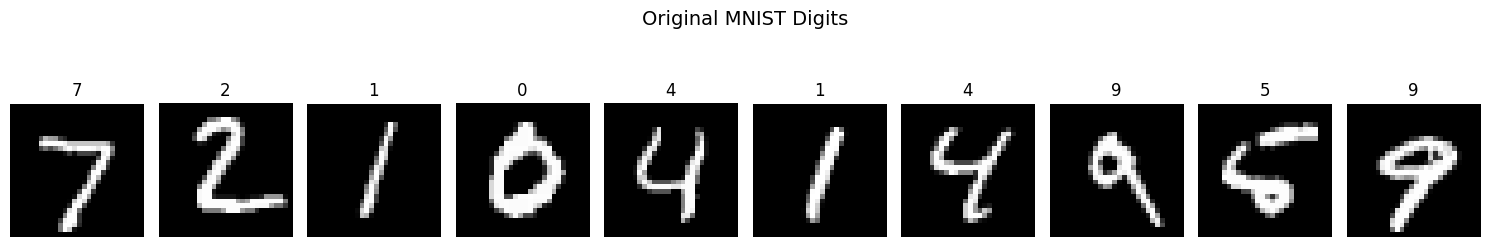

In [19]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

# Define class names
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# Visualize original images
visualize_original_images(X_test, y_test, class_names=class_names)

In [20]:
# Create model
model = create_model(input_dim=60, hidden_units=1000)

# Train model with differential privacy
history, X_train_pca, X_test_pca, pca = train_model(
    model=model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    epochs=100,
    batch_size=600,
    learning_rate=0.15,
    l2_norm_clip=3.0,
    noise_multiplier=1.1,
    delta=1e-5,
    pca_noise_scale=7.0,
    verbose=True
)

Epoch 1/100, Loss: 1492.0691, Train Accuracy: 0.2991, Test Accuracy: 0.3107, (ε=0.44, δ=1e-05)
Epoch 11/100, Loss: 3050.4072, Train Accuracy: 0.7164, Test Accuracy: 0.7181, (ε=1.45, δ=1e-05)
Epoch 21/100, Loss: 2897.4856, Train Accuracy: 0.7604, Test Accuracy: 0.7676, (ε=2.00, δ=1e-05)
Epoch 31/100, Loss: 2989.1570, Train Accuracy: 0.7875, Test Accuracy: 0.7974, (ε=2.43, δ=1e-05)
Epoch 41/100, Loss: 3137.9229, Train Accuracy: 0.8049, Test Accuracy: 0.8091, (ε=2.79, δ=1e-05)
Epoch 51/100, Loss: 3314.1418, Train Accuracy: 0.8141, Test Accuracy: 0.8233, (ε=3.12, δ=1e-05)
Epoch 61/100, Loss: 3560.1650, Train Accuracy: 0.8183, Test Accuracy: 0.8272, (ε=3.41, δ=1e-05)
Epoch 71/100, Loss: 3624.8674, Train Accuracy: 0.8271, Test Accuracy: 0.8313, (ε=3.68, δ=1e-05)
Epoch 81/100, Loss: 3905.9746, Train Accuracy: 0.8286, Test Accuracy: 0.8297, (ε=3.93, δ=1e-05)
Epoch 91/100, Loss: 4252.8755, Train Accuracy: 0.8340, Test Accuracy: 0.8350, (ε=4.16, δ=1e-05)
Epoch 100/100, Loss: 4484.8223, Train Acc

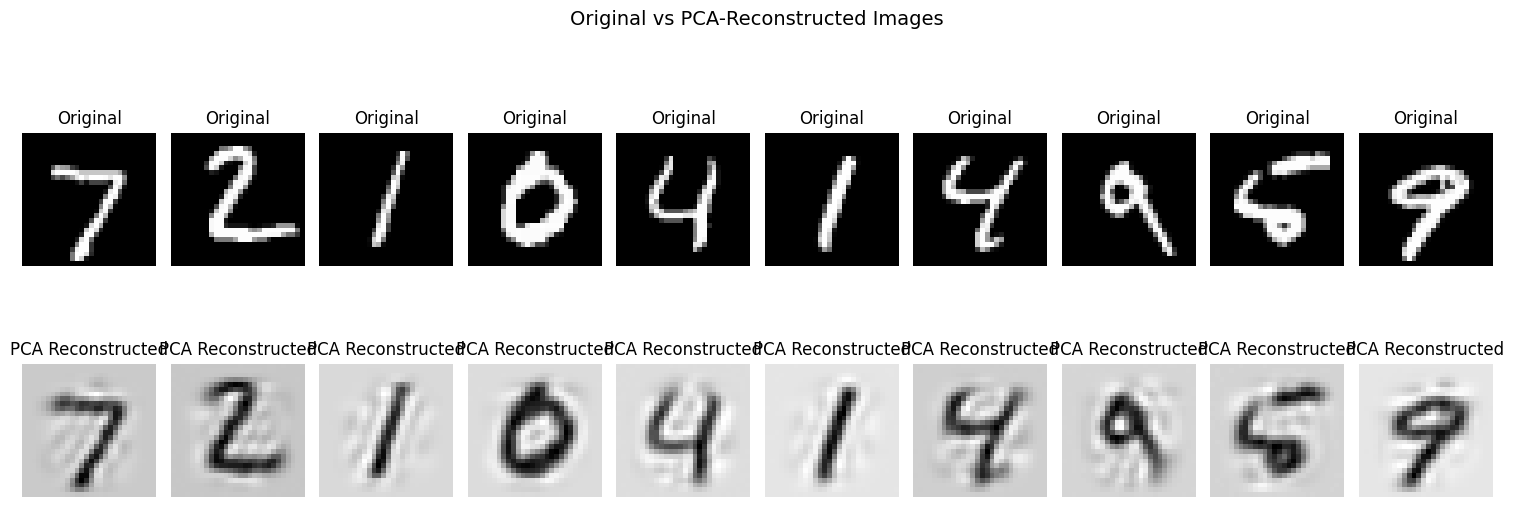

In [21]:
# Visualize PCA reconstruction
visualize_pca_reconstruction(X_test, pca)

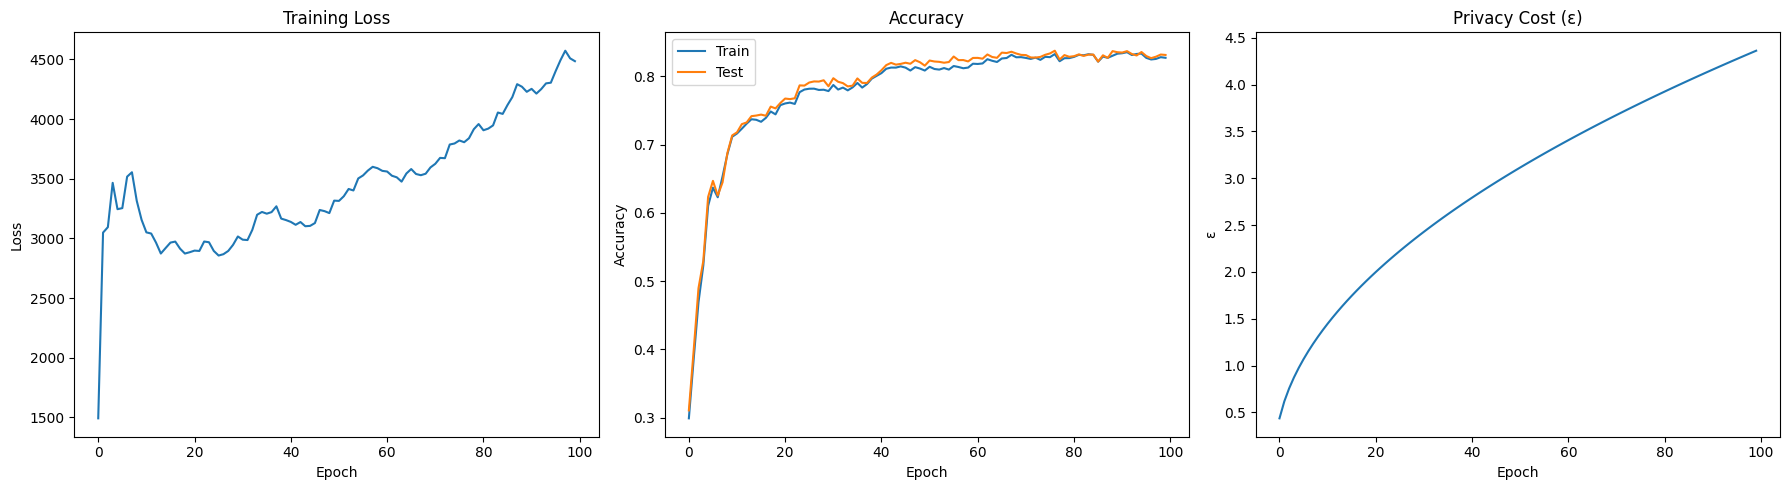

In [22]:
# Plot training results
plot_results(history)

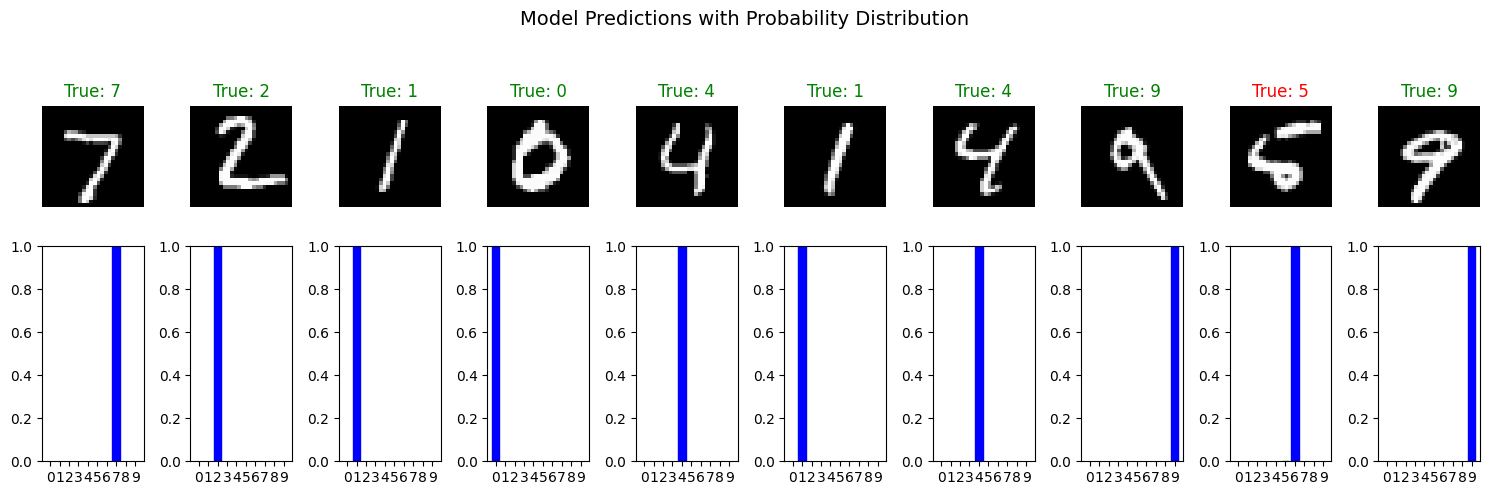

In [23]:
# Visualize model predictions
visualize_model_predictions(model, X_test_pca, X_test, y_test, class_names=class_names)

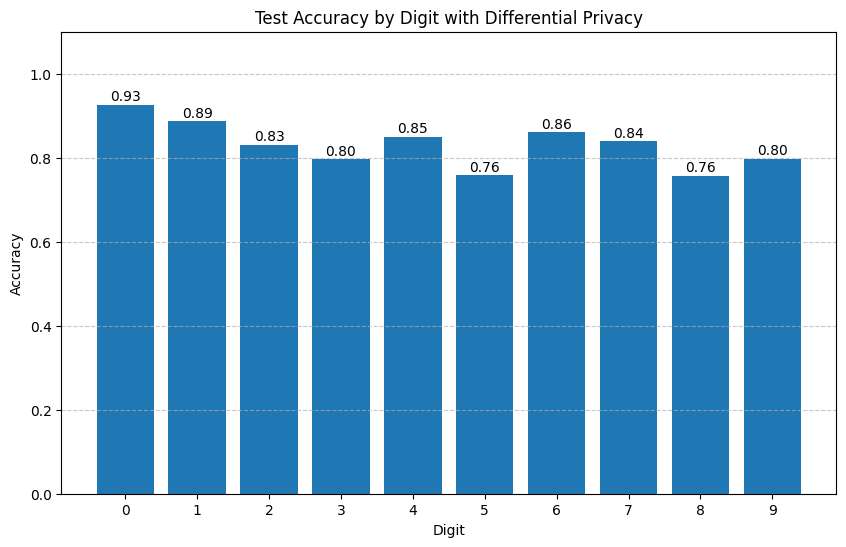

In [24]:
# Visualize accuracy by digit
visualize_accuracy_by_digit(history, class_names)

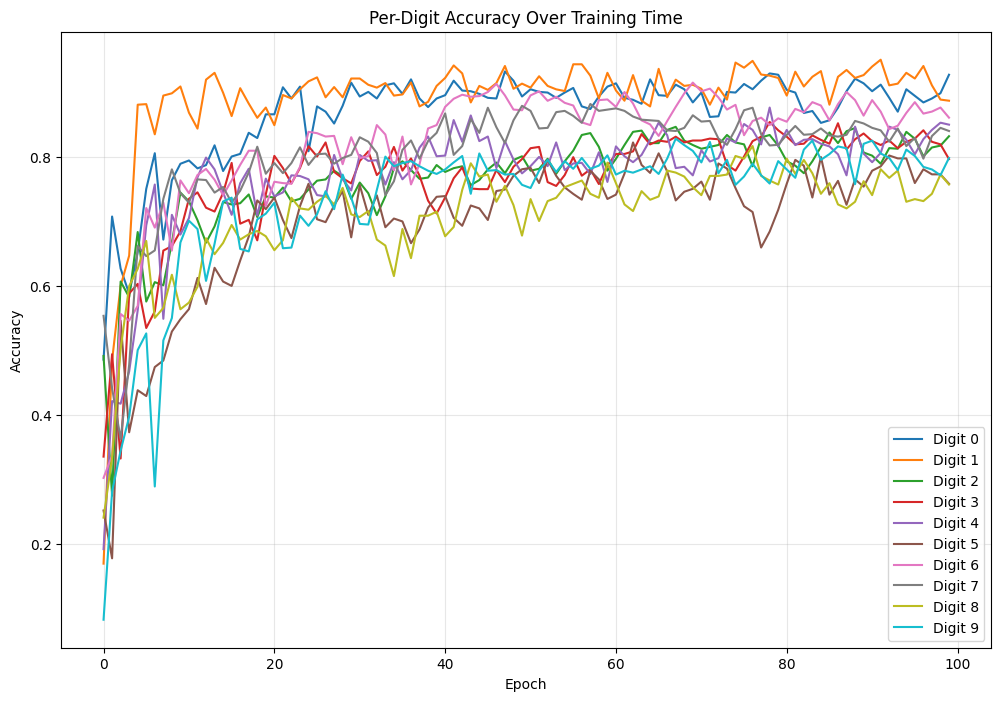

In [25]:
# Visualize per-digit accuracy over time
visualize_per_digit_accuracy_over_time(history, class_names)

In [26]:

# Define a new class to handle adjacent datasets
class AdjacentDatasetAnalyzer:
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
    
    def create_adjacent_dataset(self, index_to_remove=None):
        """
        Create an adjacent dataset by removing one sample from the training set.
        Returns the adjacent dataset and the removed sample.
        """
        if index_to_remove is None:
            # Randomly select an index to remove
            index_to_remove = np.random.randint(0, len(self.X_train))
        
        # Create a copy of the training data
        X_train_adjacent = np.copy(self.X_train)
        y_train_adjacent = np.copy(self.y_train)
        
        # Save the removed sample
        removed_sample = (X_train_adjacent[index_to_remove], y_train_adjacent[index_to_remove])
        
        # Remove the sample from the adjacent dataset
        X_train_adjacent = np.delete(X_train_adjacent, index_to_remove, axis=0)
        y_train_adjacent = np.delete(y_train_adjacent, index_to_remove)
        
        return (X_train_adjacent, y_train_adjacent), removed_sample, index_to_remove
    
    def compare_model_predictions(self, model_original, model_adjacent, X_test_pca, pca, removed_sample, n_samples=1000):
        """
        Compare predictions from models trained on original and adjacent datasets.
        """
        # Get predictions from both models
        preds_original = tf.nn.softmax(model_original(X_test_pca[:n_samples])).numpy()
        preds_adjacent = tf.nn.softmax(model_adjacent(X_test_pca[:n_samples])).numpy()
        
        # Calculate the absolute difference in predictions
        prediction_differences = np.abs(preds_original - preds_adjacent)
        
        # Calculate statistics
        mean_diff = np.mean(prediction_differences)
        max_diff = np.max(prediction_differences)
        
        # Transform removed sample for prediction
        removed_x = removed_sample[0].reshape(1, -1) / 255.0
        removed_y = removed_sample[1]
        removed_x_pca = pca.transform(removed_x.reshape(1, -1))
        
        # Get predictions for the removed sample
        removed_pred_original = tf.nn.softmax(model_original(removed_x_pca)).numpy()
        removed_pred_adjacent = tf.nn.softmax(model_adjacent(removed_x_pca)).numpy()
        
        return {
            'mean_diff': mean_diff,
            'max_diff': max_diff,
            'removed_sample_pred_original': removed_pred_original,
            'removed_sample_pred_adjacent': removed_pred_adjacent,
            'removed_sample_label': removed_y,
            'prediction_differences': prediction_differences
        }

# Define a function to train models on original and adjacent datasets and compare them
def adjacent_dataset_analysis(X_train, y_train, X_test, y_test, noise_multipliers=[0.0, 0.5, 1.1, 2.0], epochs=30):
    """
    Train models on original and adjacent datasets with different noise multipliers
    and compare their predictions to demonstrate differential privacy guarantees.
    """
    results = []
    analyzer = AdjacentDatasetAnalyzer(X_train, y_train, X_test, y_test)
    
    # Create adjacent dataset
    (X_train_adjacent, y_train_adjacent), removed_sample, removed_idx = analyzer.create_adjacent_dataset()
    
    for noise_multiplier in noise_multipliers:
        print(f"Training with noise multiplier: {noise_multiplier}")
        
        # Train model on original dataset
        model_original = create_model(input_dim=60, hidden_units=500)
        history_original, X_train_pca_original, X_test_pca, pca = train_model(
            model=model_original,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            epochs=epochs,
            batch_size=600,
            learning_rate=0.1,
            l2_norm_clip=3.0,
            noise_multiplier=noise_multiplier,
            delta=1e-5,
            pca_noise_scale=max(7.0 * noise_multiplier, 1.0),
            verbose=False
        )
        
        # Train model on adjacent dataset
        model_adjacent = create_model(input_dim=60, hidden_units=500)
        history_adjacent, X_train_pca_adjacent, _, _ = train_model(
            model=model_adjacent,
            X_train=X_train_adjacent,
            y_train=y_train_adjacent,
            X_test=X_test,
            y_test=y_test,
            epochs=epochs,
            batch_size=600,
            learning_rate=0.1,
            l2_norm_clip=3.0,
            noise_multiplier=noise_multiplier,
            delta=1e-5,
            pca_noise_scale=max(7.0 * noise_multiplier, 1.0),
            verbose=False
        )
        
        # Compare models
        comparison = analyzer.compare_model_predictions(
            model_original, model_adjacent, X_test_pca, pca, removed_sample
        )
        
        results.append({
            'noise_multiplier': noise_multiplier,
            'epsilon_original': history_original['epsilon'][-1],
            'test_accuracy_original': history_original['test_accuracy'][-1],
            'test_accuracy_adjacent': history_adjacent['test_accuracy'][-1],
            'comparison': comparison
        })
    
    return results, removed_sample, removed_idx

# Define visualization function for adjacent dataset analysis
def visualize_adjacent_dataset_results(results, removed_sample):
    plt.figure(figsize=(20, 12))
    
    # Plot 1: Mean prediction differences vs noise multiplier
    plt.subplot(2, 2, 1)
    noise_multipliers = [r['noise_multiplier'] for r in results]
    mean_diffs = [r['comparison']['mean_diff'] for r in results]
    epsilons = [r['epsilon_original'] for r in results]
    
    plt.plot(noise_multipliers, mean_diffs, 'o-', markersize=10)
    plt.xlabel('Noise Multiplier')
    plt.ylabel('Mean Prediction Difference')
    plt.title('Impact of Noise on Model Stability Across Adjacent Datasets')
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Mean prediction differences vs epsilon
    plt.subplot(2, 2, 2)
    plt.plot(epsilons, mean_diffs, 'o-', markersize=10, color='green')
    plt.xlabel('Privacy Budget (ε)')
    plt.ylabel('Mean Prediction Difference')
    plt.title('Relationship Between Privacy Budget and Model Stability')
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Prediction distributions for one example
    plt.subplot(2, 2, 3)
    for i, r in enumerate(results):
        pred_diffs = r['comparison']['prediction_differences']
        plt.hist(pred_diffs.flatten(), alpha=0.6, bins=30, 
                 label=f"Noise={r['noise_multiplier']} (ε={r['epsilon_original']:.2f})")
    
    plt.xlabel('Absolute Prediction Difference')
    plt.ylabel('Frequency')
    plt.title('Distribution of Prediction Differences Between Models')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Prediction difference for the removed sample
    plt.subplot(2, 2, 4)
    bar_width = 0.35
    index = np.arange(10)
    
    for i, r in enumerate(results):
        original_pred = r['comparison']['removed_sample_pred_original'][0]
        adjacent_pred = r['comparison']['removed_sample_pred_adjacent'][0]
        
        if i == 0:  # Only showing the first noise level for clarity
            plt.bar(index, original_pred, bar_width, label='Original Dataset')
            plt.bar(index + bar_width, adjacent_pred, bar_width, label='Adjacent Dataset')
            
            # Highlight the true label
            true_label = r['comparison']['removed_sample_label']
            plt.axvline(x=true_label + bar_width/2, color='red', linestyle='--', 
                       label=f'True Label ({true_label})')
    
    plt.xlabel('Digit Class')
    plt.ylabel('Prediction Probability')
    plt.title(f'Model Predictions for Removed Sample (Noise={results[0]["noise_multiplier"]})')
    plt.xticks(index + bar_width/2, range(10))
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # Additional plot: Test accuracy comparison
    plt.figure(figsize=(10, 6))
    noise_multipliers = [r['noise_multiplier'] for r in results]
    acc_original = [r['test_accuracy_original'] for r in results]
    acc_adjacent = [r['test_accuracy_adjacent'] for r in results]
    
    plt.plot(noise_multipliers, acc_original, 'o-', label='Original Dataset')
    plt.plot(noise_multipliers, acc_adjacent, 's-', label='Adjacent Dataset')
    
    plt.xlabel('Noise Multiplier')
    plt.ylabel('Test Accuracy')
    plt.title('Model Performance Comparison on Adjacent Datasets')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Define a function to visualize the removed sample
def visualize_removed_sample(removed_sample, removed_idx):
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(removed_sample[0], cmap='gray')
    plt.title(f"Removed Sample (Index: {removed_idx})")
    plt.xlabel(f"True Label: {removed_sample[1]}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.text(0.5, 0.5, 
             f"This sample was removed to create the adjacent dataset.\n\n"
             f"In differential privacy, adjacent datasets differ by one record.\n"
             f"Our analysis shows how removing this single sample affects\n"
             f"the model predictions with different privacy settings.",
             ha='center', va='center', fontsize=12)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


Performing Adjacent Dataset Analysis...
Training with noise multiplier: 0.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_10060\1280405073.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  epsilon = c * np.sqrt(2 * np.log(1.0/self.delta)) / self.noise_multiplier
C:\Users\Admin\AppData\Local\Temp\ipykernel_10060\1280405073.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  epsilon = c * np.sqrt(2 * np.log(1.0/self.delta)) / self.noise_multiplier


Training with noise multiplier: 0.5
Training with noise multiplier: 1.1
Training with noise multiplier: 2.0


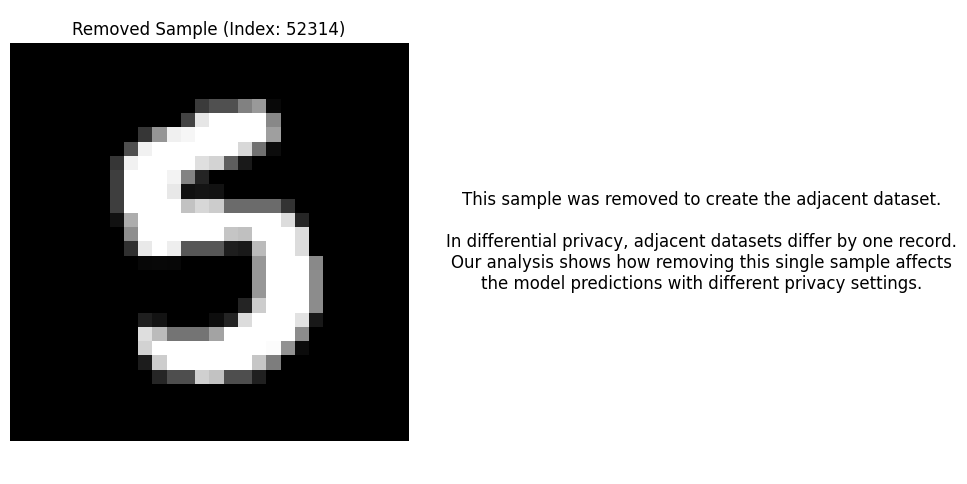

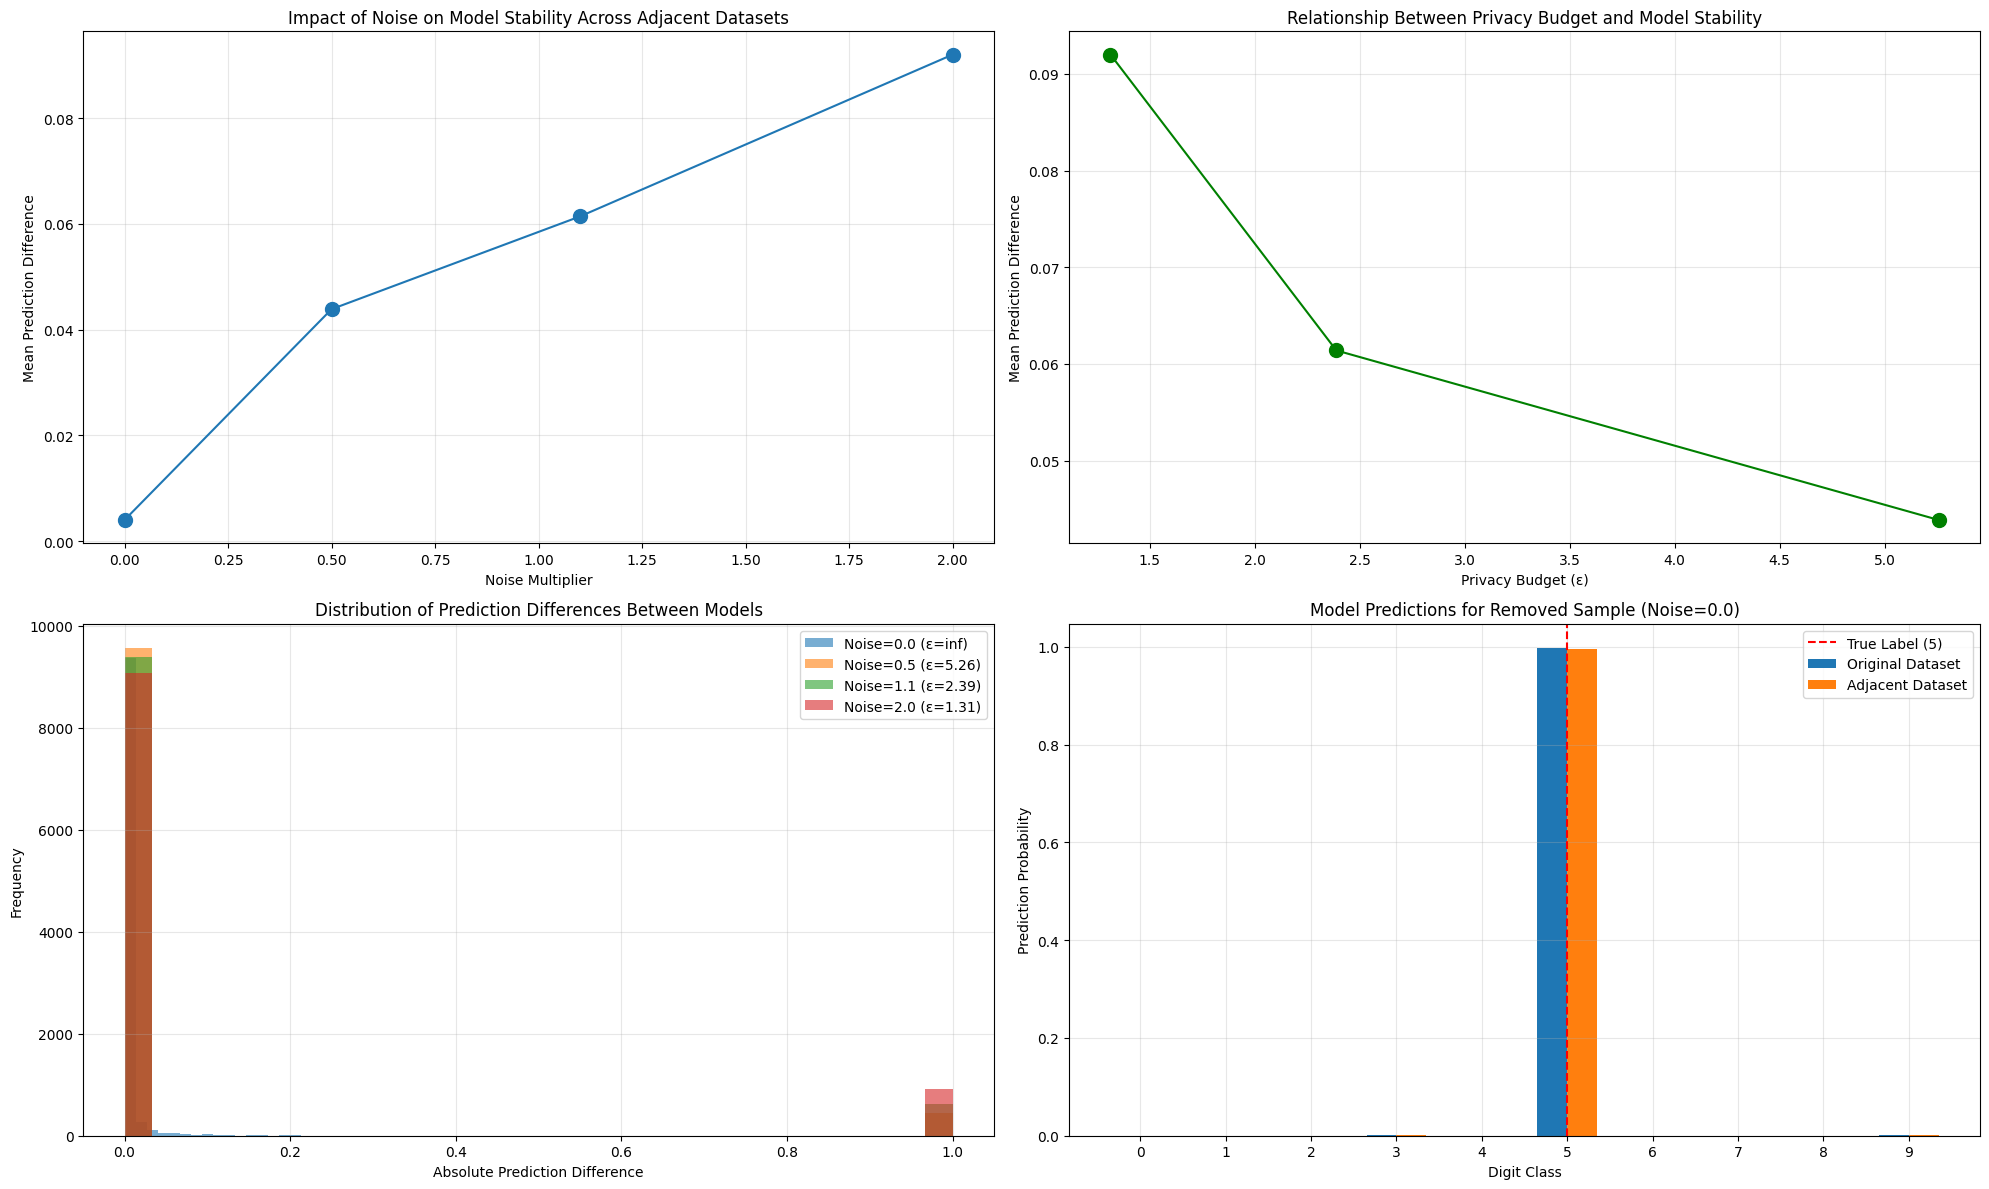

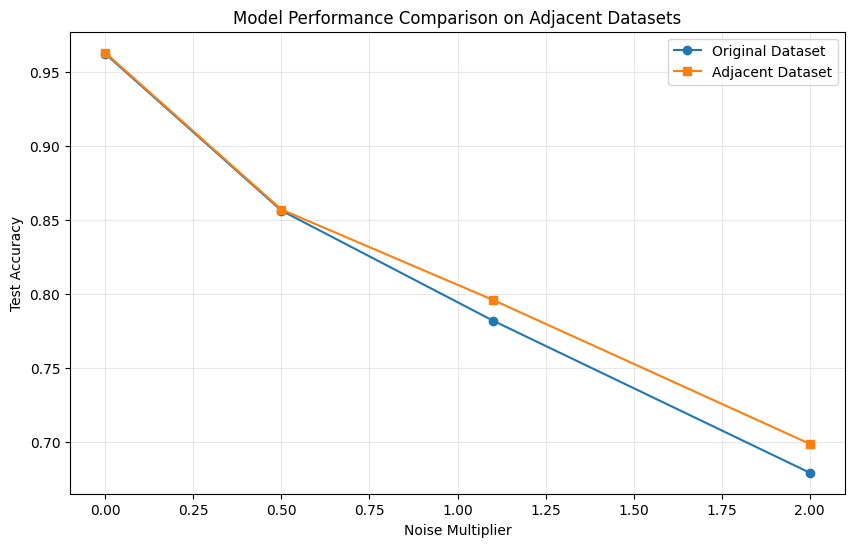

In [27]:
print("\nPerforming Adjacent Dataset Analysis...")
adjacent_results, removed_sample, removed_idx = adjacent_dataset_analysis(X_train, y_train, X_test, y_test)
visualize_removed_sample(removed_sample, removed_idx)
visualize_adjacent_dataset_results(adjacent_results, removed_sample)

In [28]:
final_epsilon = history['epsilon'][-1]
final_accuracy = history['test_accuracy'][-1]
print(f"Final Result: Test Accuracy: {final_accuracy:.4f}, (ε={final_epsilon:.2f}, δ=1e-5)")

# Calculate the average prediction difference across noise multipliers
mean_prediction_diffs = [r['comparison']['mean_diff'] for r in adjacent_results]
noise_values = [r['noise_multiplier'] for r in adjacent_results]
print("\nAdjacent Dataset Analysis Results:")
for noise, mean_diff in zip(noise_values, mean_prediction_diffs):
    epsilon = next(r['epsilon_original'] for r in adjacent_results if r['noise_multiplier'] == noise)
    print(f"  Noise Multiplier: {noise}, Privacy Budget ε: {epsilon:.2f}, Mean Prediction Difference: {mean_diff:.6f}")

# Interpret the results
highest_diff = max(mean_prediction_diffs)
lowest_diff = min(mean_prediction_diffs)
highest_noise = noise_values[mean_prediction_diffs.index(lowest_diff)]
lowest_noise = noise_values[mean_prediction_diffs.index(highest_diff)]

print("\nInterpretation:")
print(f"  * With no privacy (Noise=0), removing one sample changes predictions by {highest_diff:.6f} on average")
print(f"  * With strong privacy (Noise={highest_noise}), removing one sample only changes predictions by {lowest_diff:.6f} on average")
print(f"  * This demonstrates the effectiveness of differential privacy in protecting individual contributions to the model")

Final Result: Test Accuracy: 0.8315, (ε=4.36, δ=1e-5)

Adjacent Dataset Analysis Results:
  Noise Multiplier: 0.0, Privacy Budget ε: inf, Mean Prediction Difference: 0.004007
  Noise Multiplier: 0.5, Privacy Budget ε: 5.26, Mean Prediction Difference: 0.043866
  Noise Multiplier: 1.1, Privacy Budget ε: 2.39, Mean Prediction Difference: 0.061400
  Noise Multiplier: 2.0, Privacy Budget ε: 1.31, Mean Prediction Difference: 0.092000

Interpretation:
  * With no privacy (Noise=0), removing one sample changes predictions by 0.092000 on average
  * With strong privacy (Noise=0.0), removing one sample only changes predictions by 0.004007 on average
  * This demonstrates the effectiveness of differential privacy in protecting individual contributions to the model


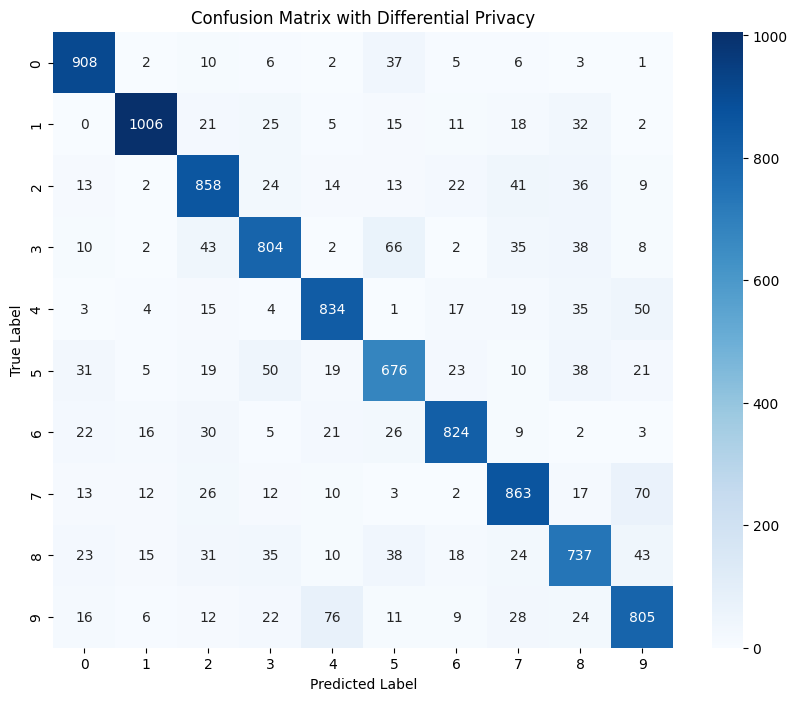

In [29]:
# Visualize confusion matrix
visualize_confusion_matrix(model, X_test_pca, y_test, class_names)

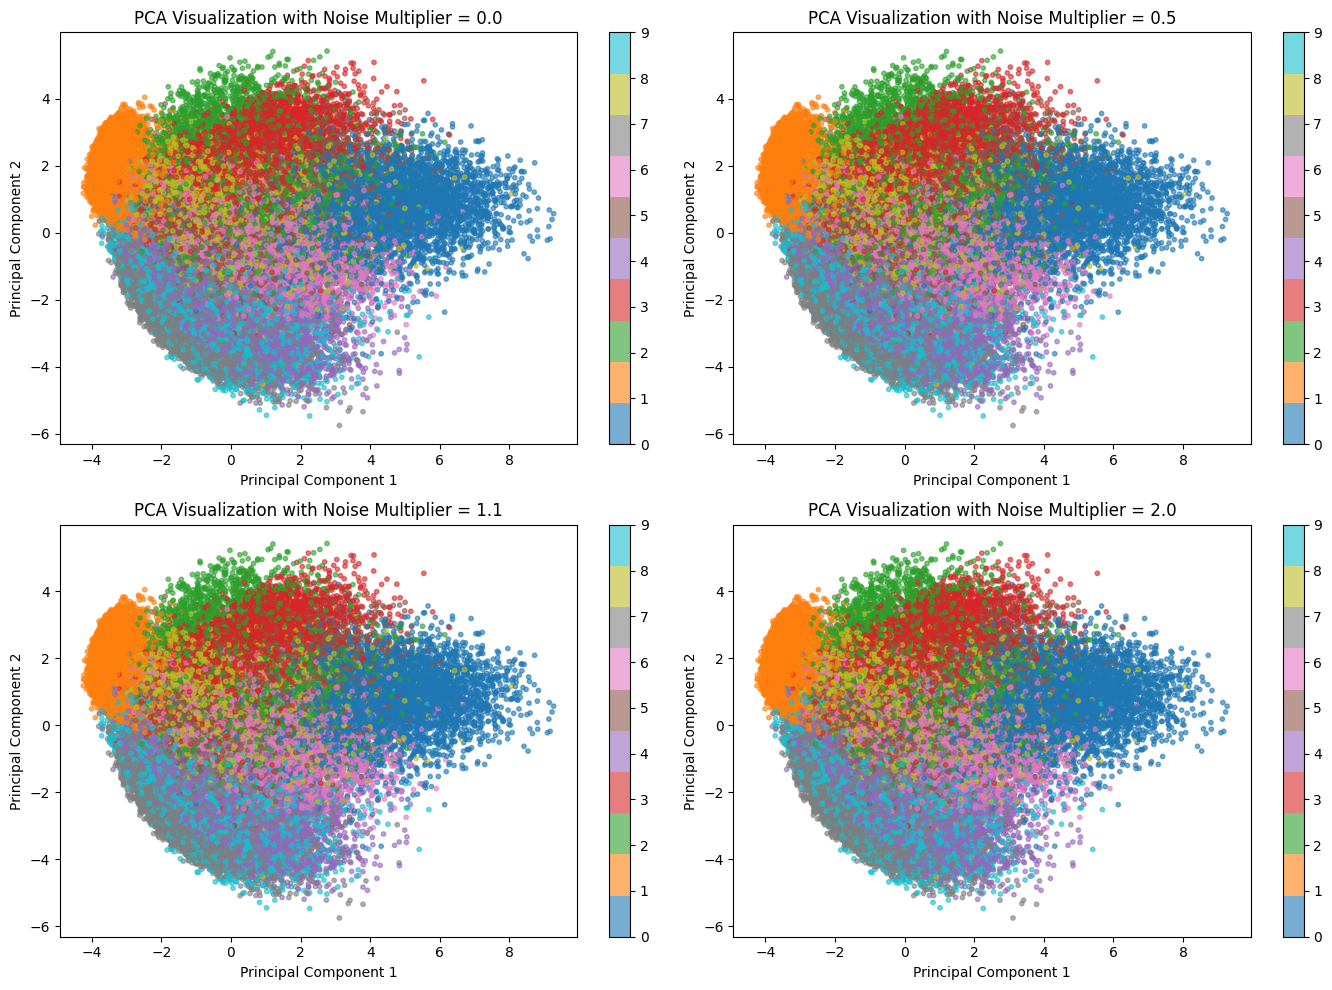

In [30]:
# Analyze privacy leakage
privacy_leakage_analysis(model, X_train, X_test, y_train, y_test, pca)

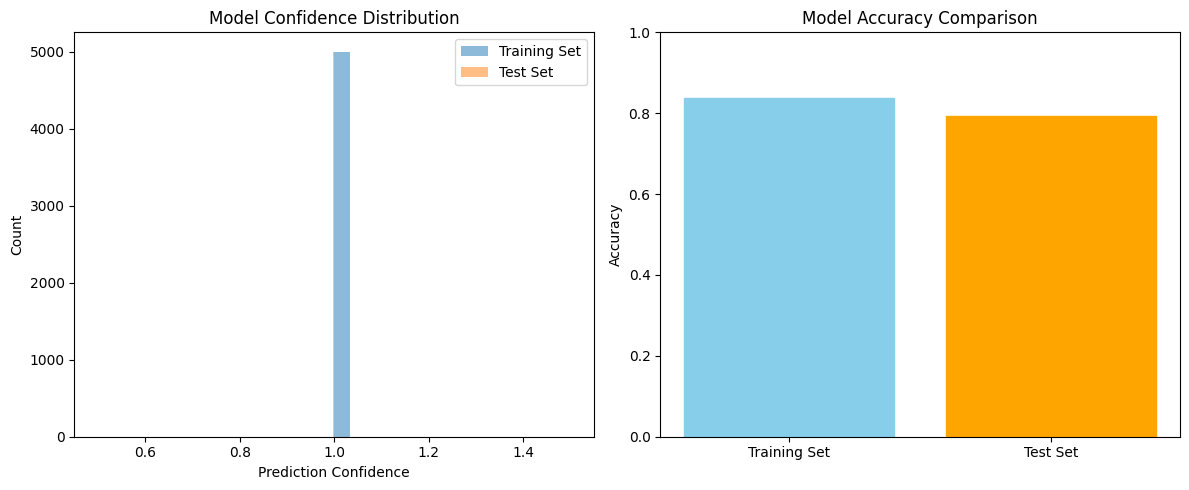

Avg confidence on training data: 1.0000
Avg confidence on test data: 1.0000
Confidence gap: 0.0000


In [31]:
# Demonstrate membership inference
membership_inference_demonstration(model, X_train_pca, X_test_pca, y_train, y_test)

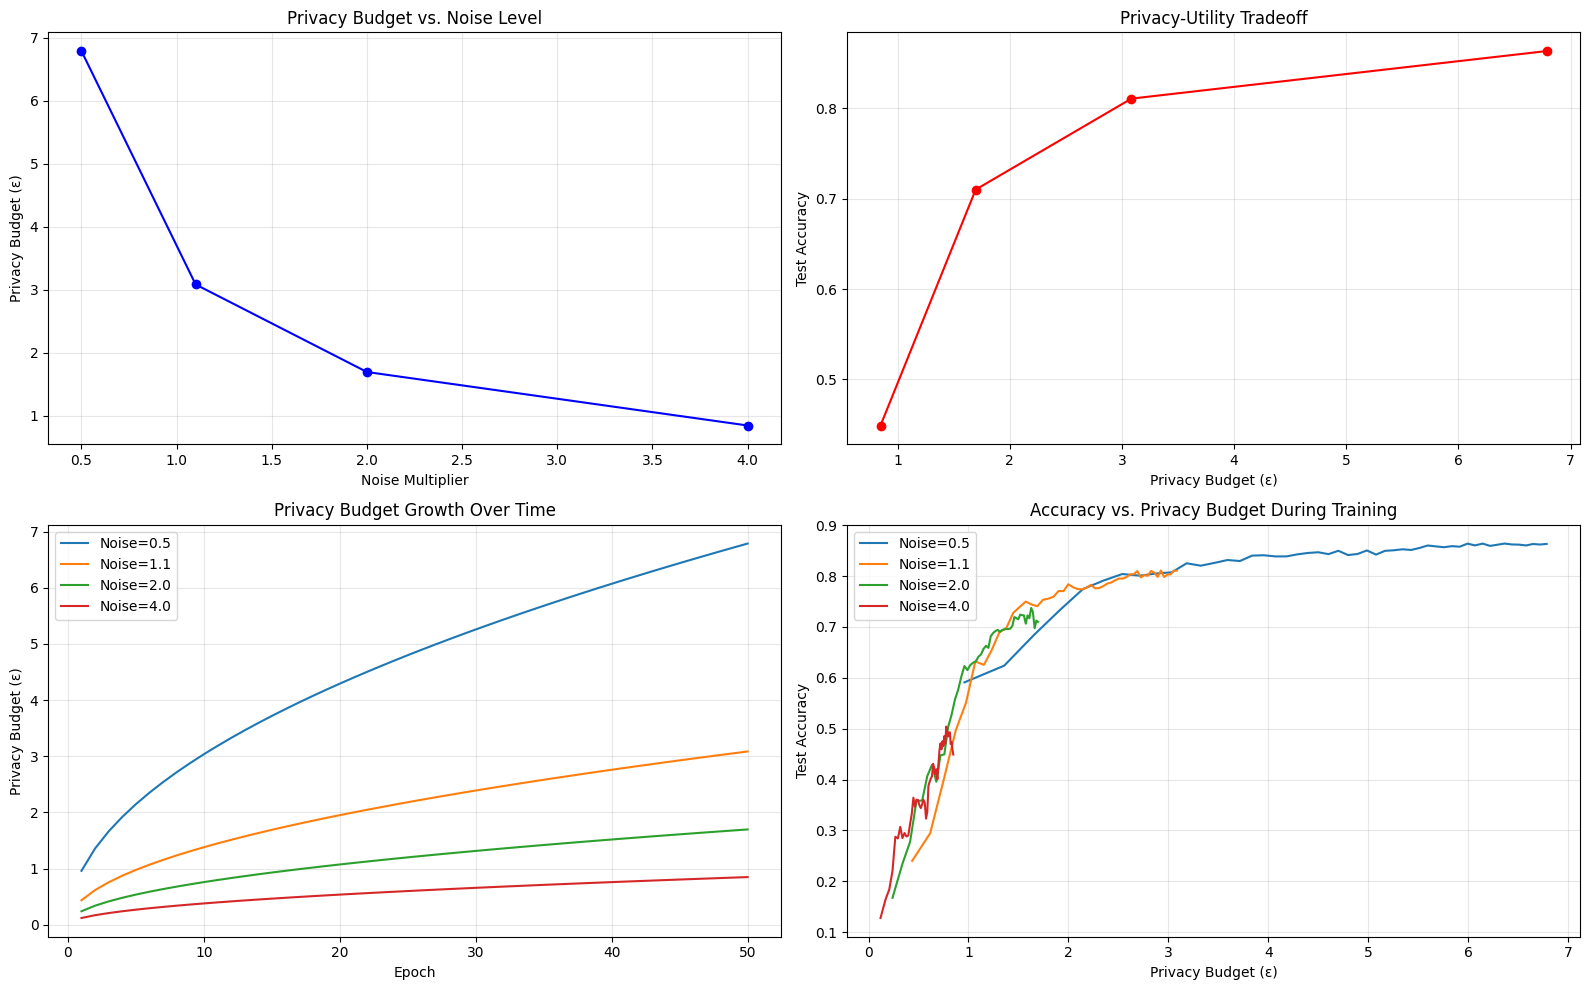

In [32]:
# Explore privacy budget
results = privacy_budget_exploration(X_train, y_train, X_test, y_test)

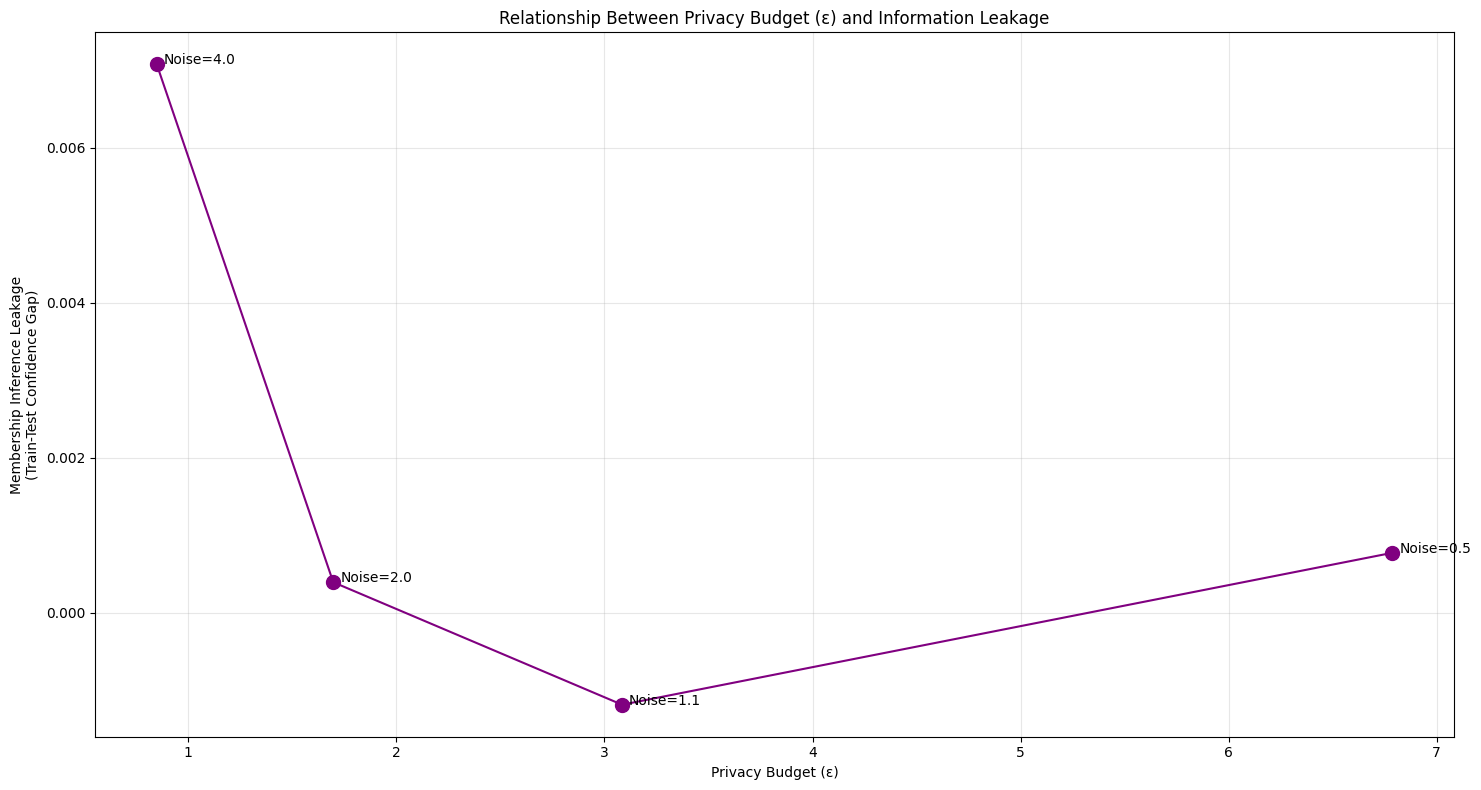

In [33]:
# Analyze correlation between epsilon and privacy leakage
epsilon_privacy_leakage_correlation(results, X_train, X_test, y_train, y_test)

In [34]:
# Print final results
final_epsilon = history['epsilon'][-1]
final_accuracy = history['test_accuracy'][-1]
print(f"Final Result: Test Accuracy: {final_accuracy:.4f}, (ε={final_epsilon:.2f}, δ=1e-5)")

Final Result: Test Accuracy: 0.8315, (ε=4.36, δ=1e-5)


Original Fashion MNIST Images:


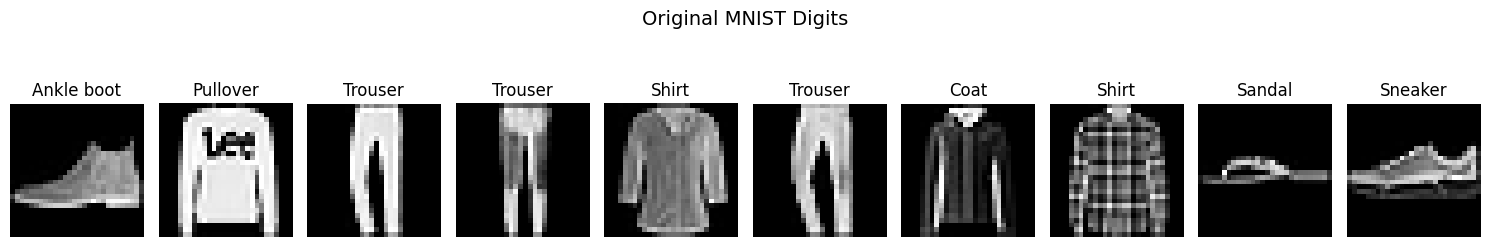

In [35]:
 # Load Fashion MNIST data
(X_train, y_train), (X_test, y_test) = datasets.fashion_mnist.load_data()
    
    # Define class names for Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    # Visualize original data
print("Original Fashion MNIST Images:")
visualize_original_images(X_test, y_test, class_names=class_names)

In [36]:
# Create model
model = create_model(input_dim=60, hidden_units=1000)

# Train model with differential privacy
history, X_train_pca, X_test_pca, pca = train_model(
    model=model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    epochs=100,
    batch_size=600,
    learning_rate=0.15,
    l2_norm_clip=3.0,
    noise_multiplier=1.1,
    delta=1e-5,
    pca_noise_scale=7.0,
    verbose=True
)

Epoch 1/100, Loss: 1171.4700, Train Accuracy: 0.4025, Test Accuracy: 0.3954, (ε=0.44, δ=1e-05)
Epoch 11/100, Loss: 3369.8862, Train Accuracy: 0.6581, Test Accuracy: 0.6508, (ε=1.45, δ=1e-05)
Epoch 21/100, Loss: 3242.0596, Train Accuracy: 0.7154, Test Accuracy: 0.7017, (ε=2.00, δ=1e-05)
Epoch 31/100, Loss: 3384.9988, Train Accuracy: 0.7074, Test Accuracy: 0.6871, (ε=2.43, δ=1e-05)
Epoch 41/100, Loss: 3551.0088, Train Accuracy: 0.7199, Test Accuracy: 0.7078, (ε=2.79, δ=1e-05)
Epoch 51/100, Loss: 4312.3306, Train Accuracy: 0.7180, Test Accuracy: 0.7089, (ε=3.12, δ=1e-05)
Epoch 61/100, Loss: 4463.1787, Train Accuracy: 0.7243, Test Accuracy: 0.7152, (ε=3.41, δ=1e-05)
Epoch 71/100, Loss: 4706.5083, Train Accuracy: 0.7282, Test Accuracy: 0.7159, (ε=3.68, δ=1e-05)
Epoch 81/100, Loss: 5159.9487, Train Accuracy: 0.7298, Test Accuracy: 0.7167, (ε=3.93, δ=1e-05)
Epoch 91/100, Loss: 5578.3799, Train Accuracy: 0.7280, Test Accuracy: 0.7162, (ε=4.16, δ=1e-05)
Epoch 100/100, Loss: 5694.8394, Train Acc

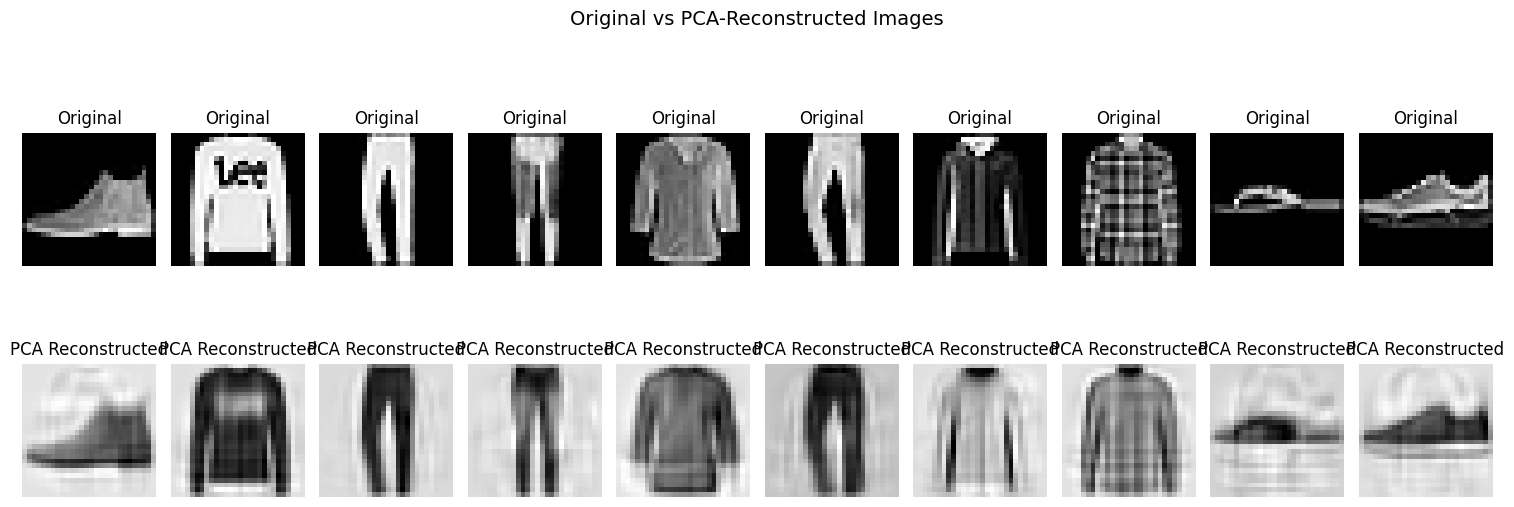

In [37]:
# Visualize PCA reconstruction
visualize_pca_reconstruction(X_test, pca)

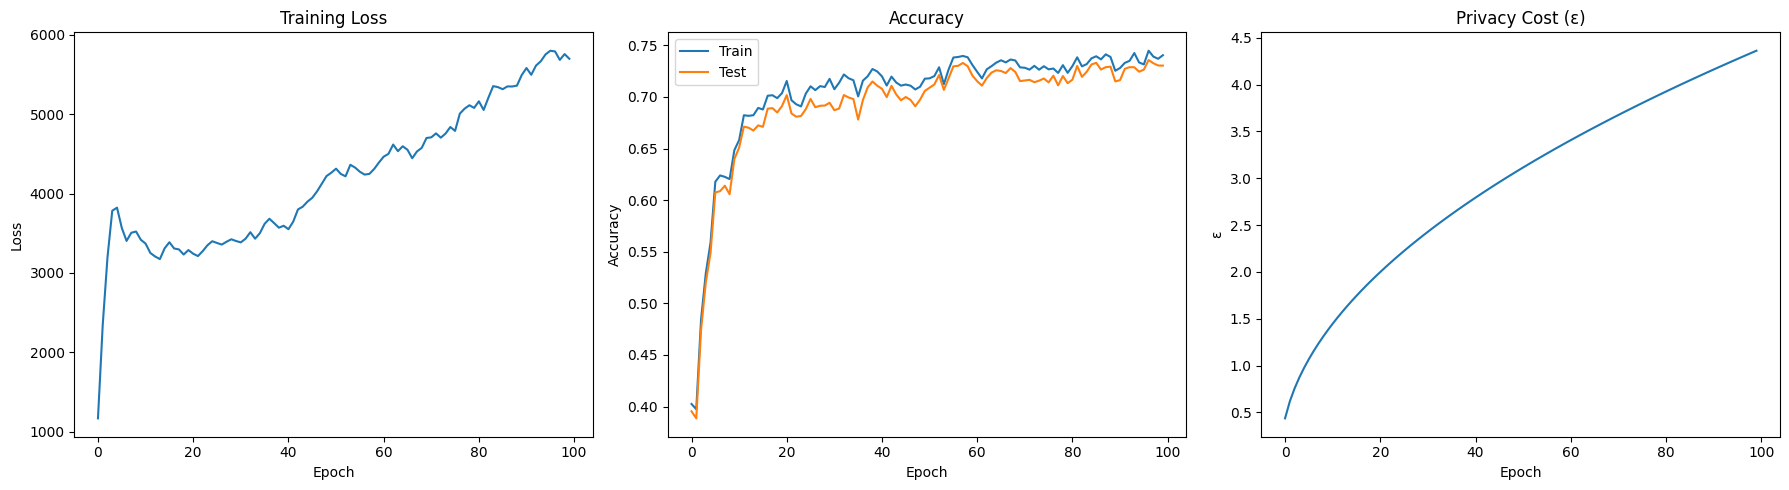

In [38]:
# Plot training results
plot_results(history)

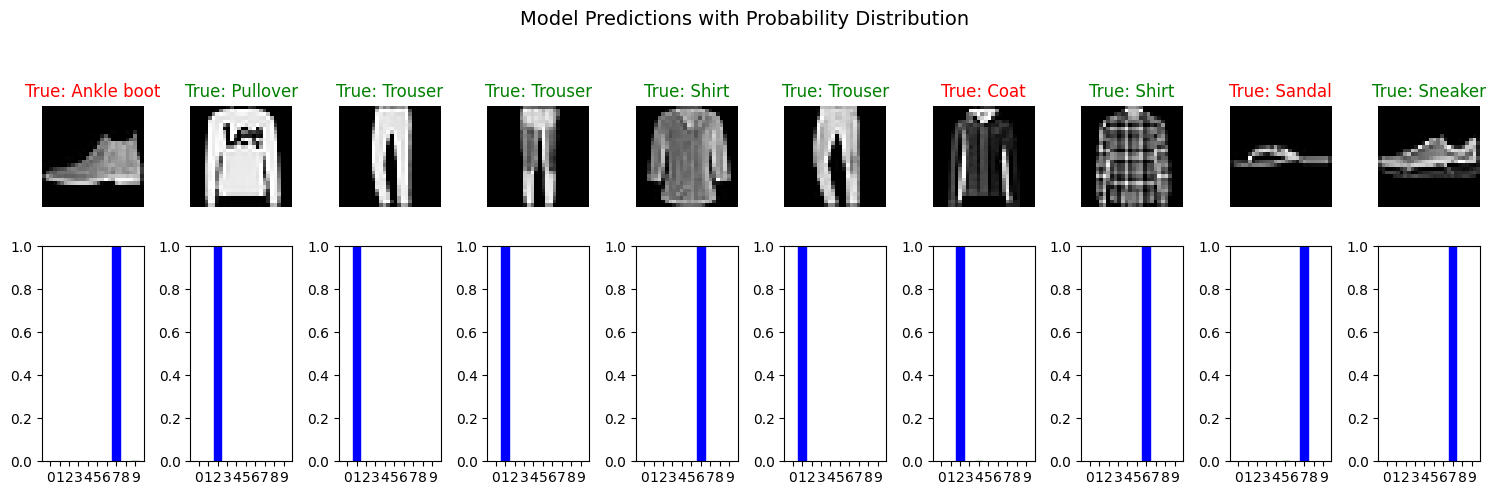

In [39]:
# Visualize model predictions
visualize_model_predictions(model, X_test_pca, X_test, y_test, class_names=class_names)

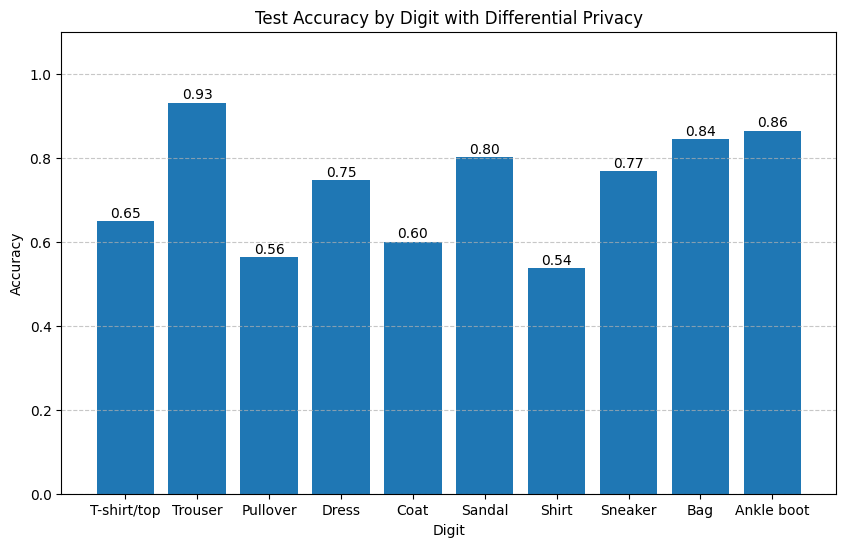

In [40]:
# Visualize accuracy by digit
visualize_accuracy_by_digit(history, class_names)

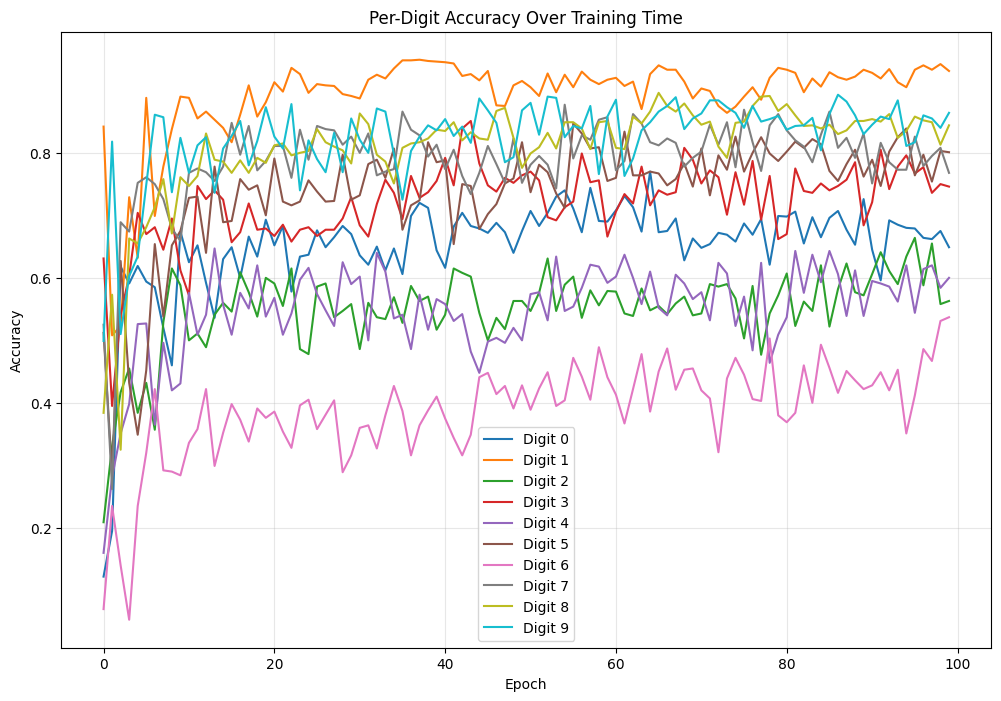

In [41]:
# Visualize per-digit accuracy over time
visualize_per_digit_accuracy_over_time(history, class_names)

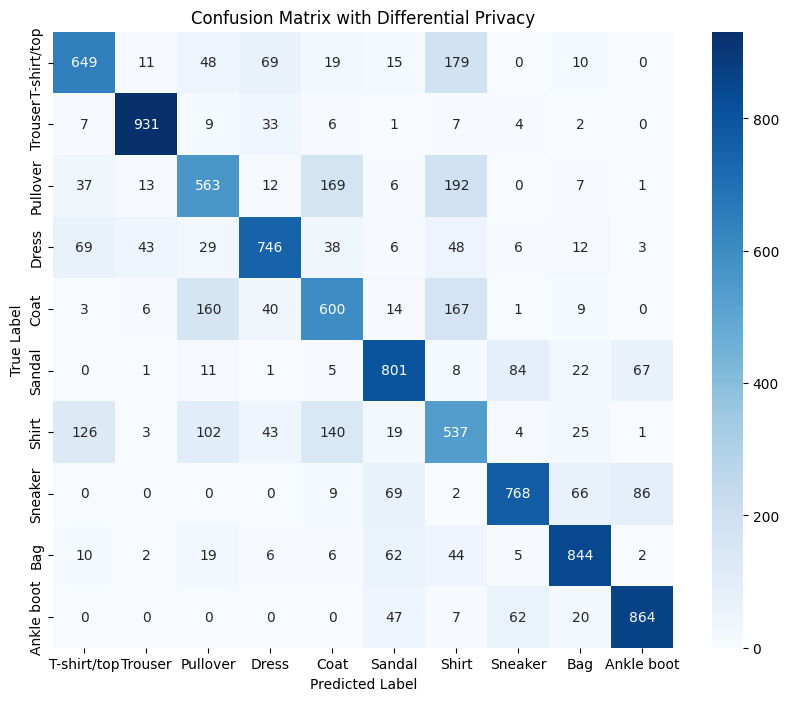

In [42]:
# Visualize confusion matrix
visualize_confusion_matrix(model, X_test_pca, y_test, class_names)

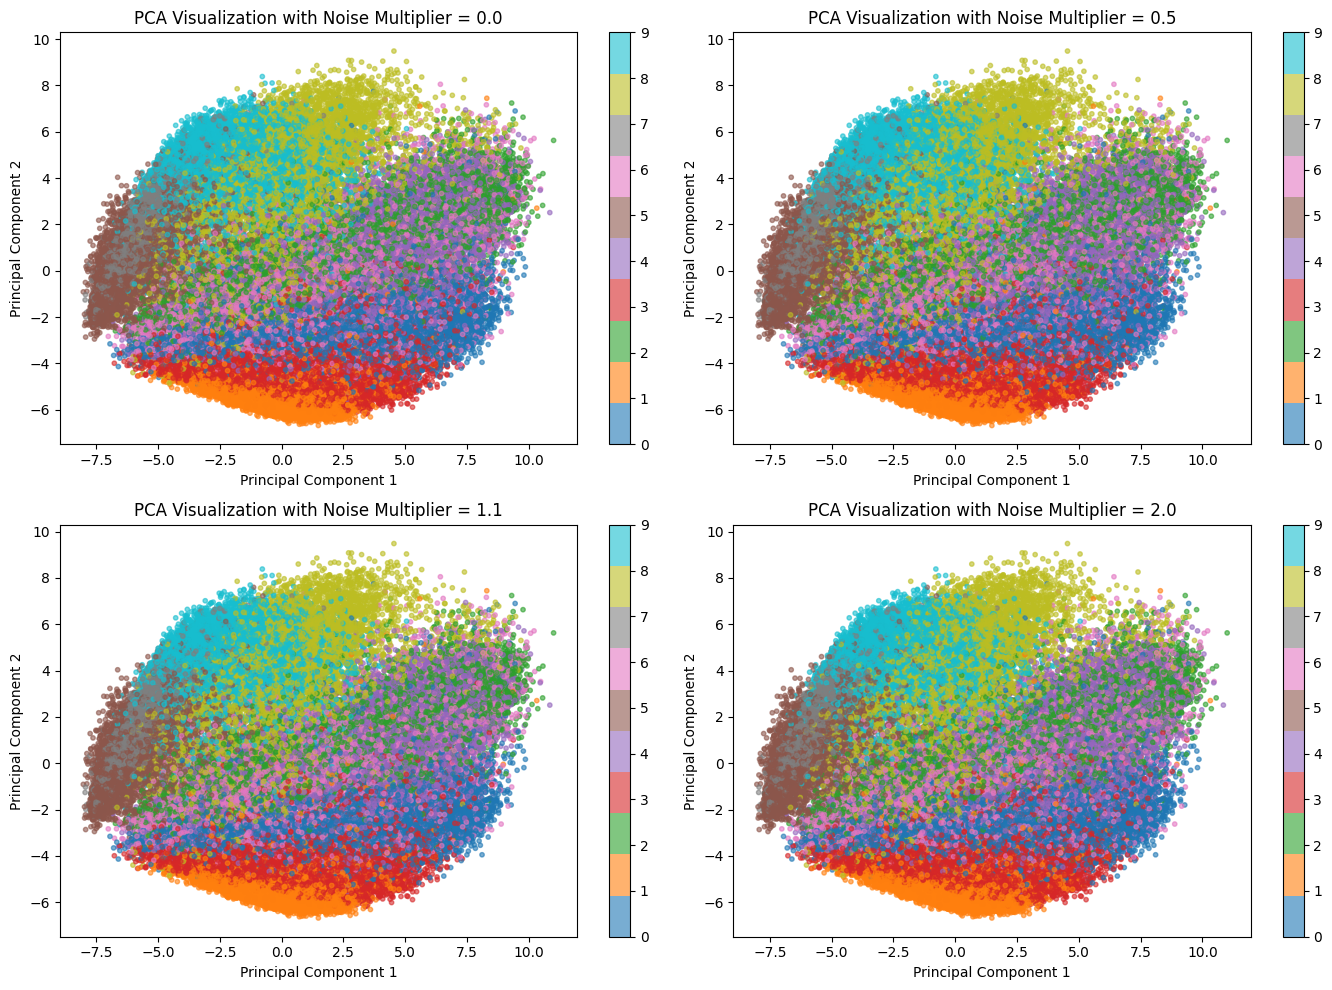

In [43]:
# Analyze privacy leakage
privacy_leakage_analysis(model, X_train, X_test, y_train, y_test, pca)

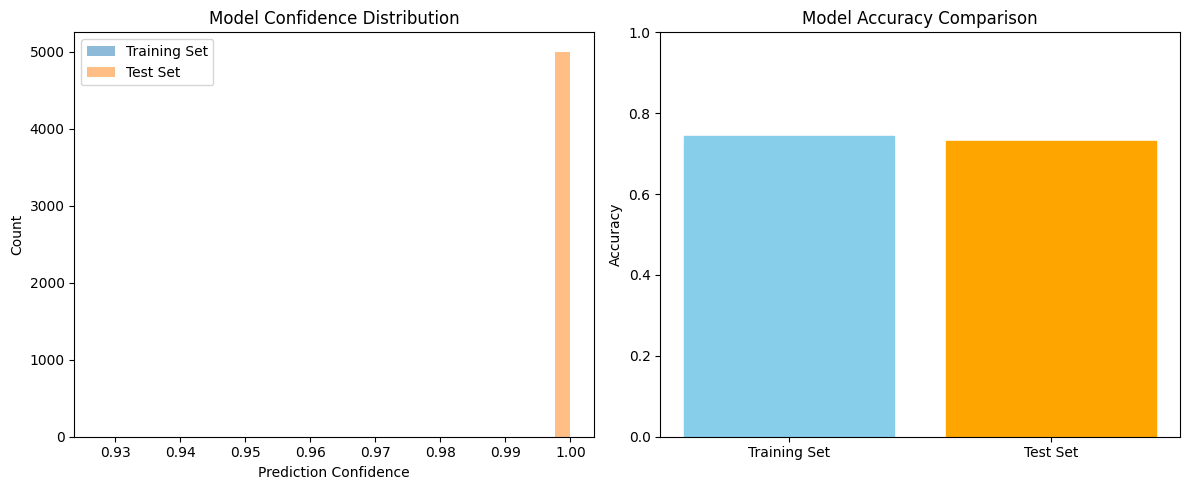

Avg confidence on training data: 1.0000
Avg confidence on test data: 1.0000
Confidence gap: 0.0000


In [44]:
# Demonstrate membership inference
membership_inference_demonstration(model, X_train_pca, X_test_pca, y_train, y_test)

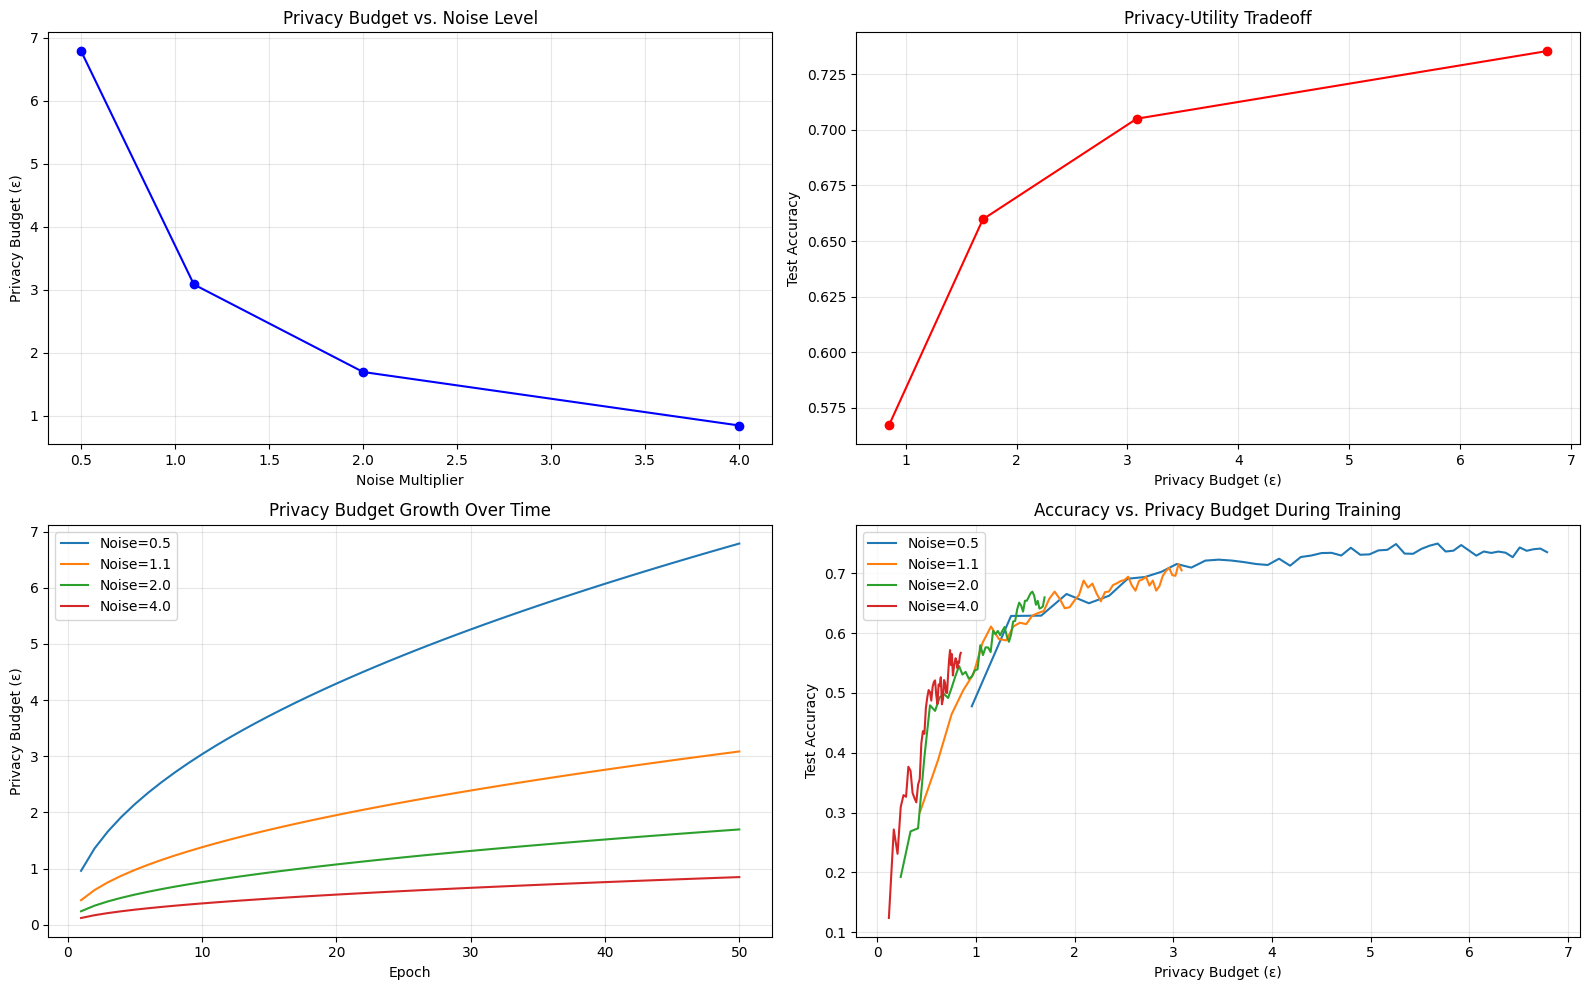

In [45]:
# Explore privacy budget
results = privacy_budget_exploration(X_train, y_train, X_test, y_test)


Performing Adjacent Dataset Analysis...
Training with noise multiplier: 0.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_10060\1280405073.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  epsilon = c * np.sqrt(2 * np.log(1.0/self.delta)) / self.noise_multiplier
C:\Users\Admin\AppData\Local\Temp\ipykernel_10060\1280405073.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  epsilon = c * np.sqrt(2 * np.log(1.0/self.delta)) / self.noise_multiplier


Training with noise multiplier: 0.5
Training with noise multiplier: 1.1
Training with noise multiplier: 2.0


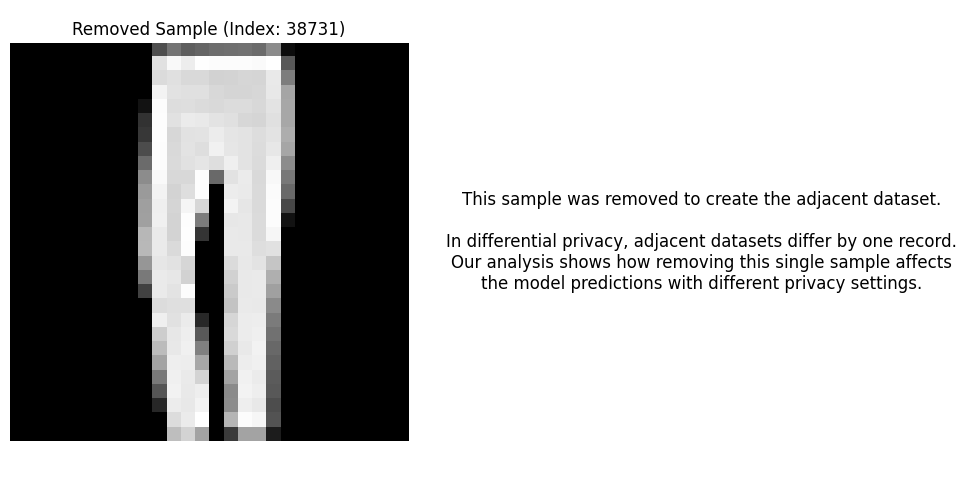

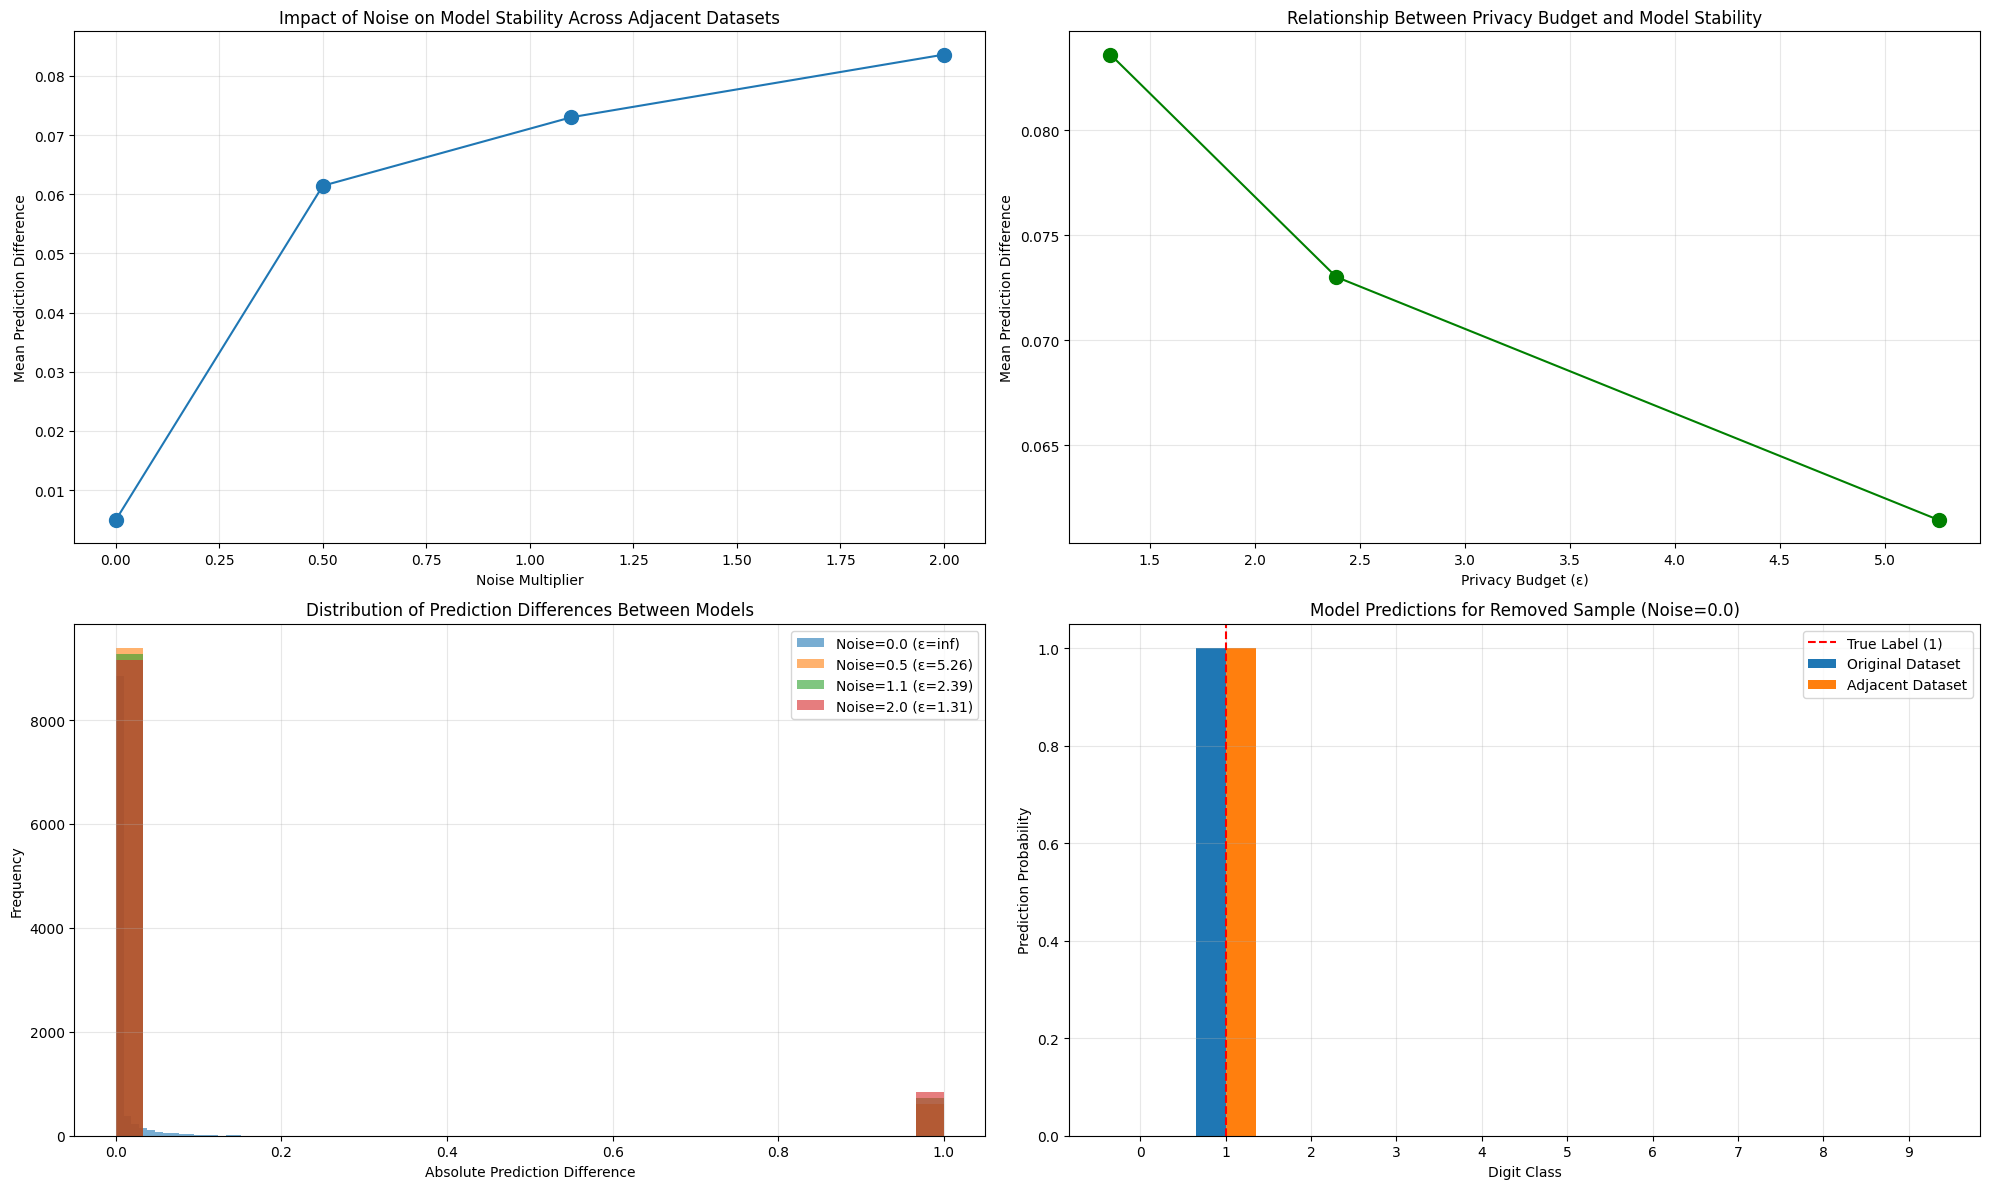

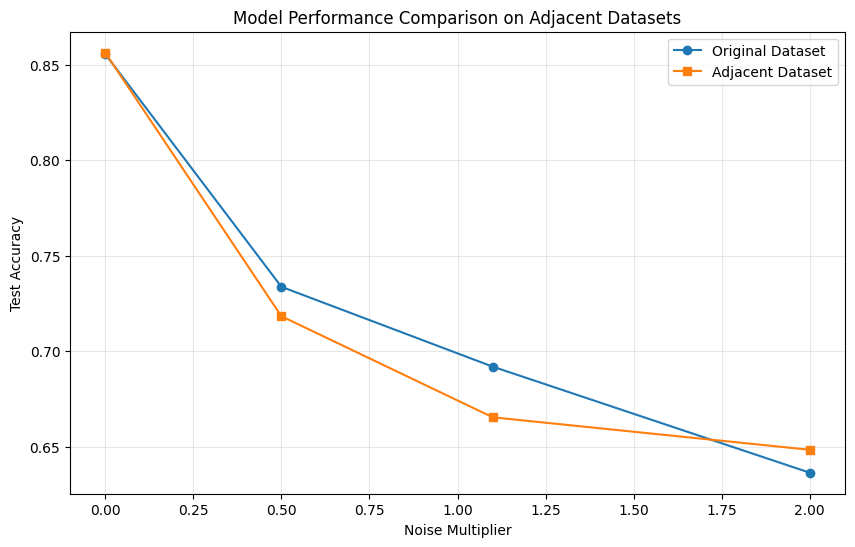

In [46]:
print("\nPerforming Adjacent Dataset Analysis...")
adjacent_results, removed_sample, removed_idx = adjacent_dataset_analysis(X_train, y_train, X_test, y_test)
visualize_removed_sample(removed_sample, removed_idx)
visualize_adjacent_dataset_results(adjacent_results, removed_sample)